In [1]:
# =============================================================================
# CELDA 1 MODIFICADA: CONFIGURACIÓN Y CARGA CON LAS 4 VARIABLES SIGNIFICATIVAS
# =============================================================================

print("=" * 80)
print("ANÁLISIS PROFESIONAL - REGRESIÓN MULTIVARIABLE CON 4 VARIABLES CLAVE")
print("BASADO EN ANÁLISIS DE CORRELACIÓN PREVIO")
print("=" * 80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os
import sys
from datetime import datetime
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from scipy import stats
import joblib
from sklearn.utils import resample

# Configuración completa
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

class Config:
    DATA_PATH = r"C:\Users\PC\Desktop\ProjecteData\Equip_15\Data\RRHH_220925_clean.parquet"
    OUTPUT_BASE = r"G:\Mi unidad\IT ACADEMY\Reskilling Data Analytics\Simulador Empresarial\Results"
    
    @property
    def OUTPUT_PATH(self):
        return os.path.join(self.OUTPUT_BASE, "Analisis_Ausentismo_Regresiones_Multivariables_2909254_ACTUAL_A_041025")

config = Config()
os.makedirs(config.OUTPUT_PATH, exist_ok=True)

# DEFINIR LAS 4 VARIABLES SIGNIFICATIVAS DEL ANÁLISIS PREVIO
variables_especificas = [
    'Disciplinary_failure', 
    'Social_drinker', 
    'Son', 
    'Transportation_expense'
]

print(f"🎯 VARIABLES SELECCIONADAS BASADAS EN ANÁLISIS DE CORRELACIÓN:")
for i, var in enumerate(variables_especificas, 1):
    print(f"  {i}. {var}")

def clasificar_fuerza_mejorada(coef_estandarizado, p_value):
    """Clasificación mejorada de fuerza con significancia"""
    abs_coef = abs(coef_estandarizado)
    
    if p_value > 0.05:
        return "NO SIGNIFICATIVA", "⚪", 0
    
    if abs_coef >= 0.7:
        return "FUERTE", "🔴", 3
    elif abs_coef >= 0.3:
        return "MODERADA", "🟡", 2
    elif abs_coef >= 0.1:
        return "DÉBIL", "🟢", 1
    else:
        return "MUY DÉBIL", "⚪", 0

def convertir_tipos_datos_seguro(df):
    """
    Convierte las columnas a los tipos de datos correctos de forma segura
    """
    print("🔄 CONVIRTIENDO TIPOS DE DATOS...")
    
    # Mapeo de conversiones seguras para nuestras 4 variables
    conversiones = {
        'Absenteeism_hours': 'float',
        'Transportation_expense': 'float',
        'Son': 'float',
        'Disciplinary_failure': 'float',
        'Social_drinker': 'float'
    }
    
    df_corregido = df.copy()
    reporte_conversiones = {}
    
    for columna, tipo_destino in conversiones.items():
        if columna in df_corregido.columns:
            try:
                # Guardar valores originales para el reporte
                valores_unicos_originales = df_corregido[columna].unique()[:5]
                tipo_original = df_corregido[columna].dtype
                
                # Conversión segura
                if tipo_destino == 'float':
                    df_corregido[columna] = pd.to_numeric(df_corregido[columna], errors='coerce')
                
                tipo_final = df_corregido[columna].dtype
                n_nulos = df_corregido[columna].isnull().sum()
                
                reporte_conversiones[columna] = {
                    'original': tipo_original,
                    'final': tipo_final,
                    'valores_originales': valores_unicos_originales,
                    'nulos_creados': n_nulos
                }
                
                print(f"   ✓ {columna:25} {str(tipo_original):10} → {str(tipo_final):10} | Nulos: {n_nulos}")
                
            except Exception as e:
                print(f"   ❌ Error convirtiendo {columna}: {e}")
                reporte_conversiones[columna] = {
                    'error': str(e),
                    'original': df_corregido[columna].dtype
                }
    
    return df_corregido, reporte_conversiones

def analizar_calidad_datos(df):
    """Análisis completo de calidad de datos"""
    print(f"\n🔍 ANÁLISIS DE CALIDAD DE DATOS:")
    print(f"• Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
    print(f"• Valores nulos totales: {df.isnull().sum().sum()}")
    print(f"• Duplicados exactos: {df.duplicated().sum()}")
    
    print(f"• LAS 4 VARIABLES CLAVE Y SUS CARACTERÍSTICAS:")
    
    for var in variables_especificas + ['Absenteeism_hours']:
        if var in df.columns:
            n_nulos = df[var].isnull().sum()
            n_unicos = df[var].nunique()
            tipo = df[var].dtype
            print(f"  - {var:25} | Nulos: {n_nulos:3} | Únicos: {n_unicos:3} | Tipo: {tipo}")

# Cargar datos con manejo de errores
print("📊 CARGANDO DATOS...")
try:
    df = pd.read_parquet(config.DATA_PATH)
    print(f"✅ Dataset cargado exitosamente: {df.shape[0]} filas, {df.shape[1]} columnas")
    
    # Mostrar primeras filas para verificación
    print(f"\n📋 MUESTRA DE DATOS (primeras 3 filas):")
    print(df.head(3))
    
except Exception as e:
    print(f"❌ ERROR cargando datos: {e}")
    sys.exit(1)

# CONVERSIÓN DE TIPOS DE DATOS PRIMERO
print(f"\n🔄 CONVERSIÓN DE TIPOS DE DATOS...")
df, reporte_conversiones = convertir_tipos_datos_seguro(df)

# Mostrar resumen de conversiones
print(f"\n📊 RESUMEN DE CONVERSIONES:")
for columna, info in reporte_conversiones.items():
    if 'error' in info:
        print(f"• {columna}: ❌ ERROR - {info['error']}")
    else:
        print(f"• {columna}: {info['original']} → {info['final']} | Nulos: {info['nulos_creados']}")

# Análisis de calidad de datos después de la conversión
analizar_calidad_datos(df)

# Filtrar datos para análisis
print(f"\n🎯 PREPARANDO DATOS PARA ANÁLISIS...")
df_filtered = df.copy()
print(f"✅ No se aplicó filtro: {len(df_filtered)} registros totales")

# Verificar que tenemos suficientes datos después del filtrado
if len(df_filtered) < 10:
    print("❌ ERROR: Muy pocos registros después del filtrado. Revisar los datos.")
    sys.exit(1)

# Verificar que todas las variables existen y son numéricas
variables_faltantes = [var for var in variables_especificas if var not in df_filtered.columns]
if variables_faltantes:
    print(f"❌ ERROR: Variables faltantes: {variables_faltantes}")
    sys.exit(1)

# Verificar tipos de datos
print(f"\n🔍 VERIFICANDO TIPOS DE DATOS FINALES:")
for var in variables_especificas + ['Absenteeism_hours']:
    if var in df_filtered.columns:
        tipo = df_filtered[var].dtype
        n_nulos = df_filtered[var].isnull().sum()
        print(f"  - {var:25} | Tipo: {str(tipo):10} | Nulos: {n_nulos}")

print(f"✅ Todas las 4 variables necesarias están disponibles")

# Preparar datos para el modelo
X = df_filtered[variables_especificas].copy()
y = df_filtered['Absenteeism_hours'].copy()

# Calcular métricas clave
horas_promedio = y.mean()
horas_total = y.sum()
horas_std = y.std()

print(f"\n📊 MÉTRICAS CLAVE DEL ANÁLISIS:")
print(f"• Variable objetivo: Absenteeism_hours")
print(f"• Variables predictoras: {len(variables_especificas)}")
print(f"• Horas totales de ausentismo: {horas_total:.0f} horas")
print(f"• Horas promedio por empleado: {horas_promedio:.2f} horas")
print(f"• Desviación estándar: {horas_std:.2f} horas")
print(f"• Rango de ausentismo: [{y.min():.1f} - {y.max():.1f}] horas")

# Análisis de distribución del ausentismo
print(f"\n📈 DISTRIBUCIÓN DEL AUSENTISMO:")
print(f"• Mediana: {y.median():.2f} horas")
print(f"• Asimetría: {y.skew():.2f}")
print(f"• Curtosis: {y.kurtosis():.2f}")

# Análisis por percentiles
print(f"\n🎯 ANÁLISIS POR PERCENTILES:")
percentiles = [25, 50, 75, 90, 95, 99]
for p in percentiles:
    valor = np.percentile(y, p)
    print(f"• P{p:2}: {valor:6.2f} horas")

# ANÁLISIS ESPECÍFICO DE CADA VARIABLE
print(f"\n🔍 ANÁLISIS ESPECÍFICO POR VARIABLE:")

for var in variables_especificas:
    print(f"\n• {var}:")
    
    if var in ['Transportation_expense', 'Son']:
        # Variables numéricas
        stats = X[var].describe()
        print(f"  - Media: {stats['mean']:.2f}")
        print(f"  - Mediana: {X[var].median():.2f}")
        print(f"  - Std: {stats['std']:.2f}")
        print(f"  - Rango: [{stats['min']:.1f} - {stats['max']:.1f}]")
        print(f"  - Asimetría: {X[var].skew():.2f}")
        
        # Correlación con ausentismo
        correlacion_pearson = X[var].corr(y)
        correlacion_spearman = X[var].corr(y, method='spearman')
        print(f"  - Correlación Pearson: {correlacion_pearson:.4f}")
        print(f"  - Correlación Spearman: {correlacion_spearman:.4f}")
        
    else:
        # Variables binarias
        for valor in sorted(X[var].unique()):
            if not pd.isna(valor):
                mascara = X[var] == valor
                count = mascara.sum()
                porcentaje = (count / len(X)) * 100
                ausentismo_promedio = y[mascara].mean() if count > 0 else 0
                print(f"  - Valor {valor}: {count:3} personas ({porcentaje:5.1f}%) - {ausentismo_promedio:.2f} horas promedio")

# Análisis de Transportation_expense por cuartiles
if 'Transportation_expense' in X.columns:
    print(f"\n📊 ANÁLISIS DETALLADO - TRANSPORTATION_EXPENSE:")
    X['Transportation_quartile'] = pd.qcut(X['Transportation_expense'], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    
    for quartil in ['Q1', 'Q2', 'Q3', 'Q4']:
        mascara = X['Transportation_quartile'] == quartil
        if mascara.any():
            horas_promedio_quartil = y[mascara].mean()
            horas_std_quartil = y[mascara].std()
            count = mascara.sum()
            gasto_promedio = X.loc[mascara, 'Transportation_expense'].mean()
            print(f"  - {quartil}: {count:3} personas - Gasto: {gasto_promedio:.1f} - Ausentismo: {horas_promedio_quartil:.2f} ± {horas_std_quartil:.2f} horas")

# Guardar información del análisis inicial
print(f"\n💾 GUARDANDO INFORMACIÓN DEL ANÁLISIS INICIAL...")

# Crear resumen inicial
resumen_inicial = {
    'timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'total_registros': len(df),
    'registros_filtrados': len(df_filtered),
    'horas_promedio_ausentismo': float(horas_promedio),
    'horas_total_ausentismo': float(horas_total),
    'variables_analizadas': variables_especificas,
    'conversiones_realizadas': len(reporte_conversiones)
}

# Guardar resumen inicial
import json
with open(f'{config.OUTPUT_PATH}/resumen_inicial.json', 'w', encoding='utf-8') as f:
    json.dump(resumen_inicial, f, indent=2, ensure_ascii=False)

print(f"✅ CELDA 1 COMPLETADA EXITOSAMENTE")
print(f"📁 Resultados guardados en: {config.OUTPUT_PATH}")
print(f"📊 Datos preparados para análisis: {X.shape[0]} observaciones, {X.shape[1]} variables")
print(f"🎯 Variable objetivo: {y.shape[0]} valores, promedio: {horas_promedio:.2f} horas")

ANÁLISIS PROFESIONAL - REGRESIÓN MULTIVARIABLE CON 4 VARIABLES CLAVE
BASADO EN ANÁLISIS DE CORRELACIÓN PREVIO
🎯 VARIABLES SELECCIONADAS BASADAS EN ANÁLISIS DE CORRELACIÓN:
  1. Disciplinary_failure
  2. Social_drinker
  3. Son
  4. Transportation_expense
📊 CARGANDO DATOS...
✅ Dataset cargado exitosamente: 806 filas, 26 columnas

📋 MUESTRA DE DATOS (primeras 3 filas):
   ID                                     Reason_absence Month_absence  \
0  14                 Enfermedades del sistema digestivo     Noviembre   
1  36  Enfermedades del sistema musculoesquelético y ...         Abril   
2   9                  Enfermedades del sistema nervioso         Julio   

    Day_week    Seasons  Transportation_expense  Distance_Residence_Work  \
0      Lunes  Primavera                   155.0                     12.0   
1  Miercoles     Verano                   118.0                     13.0   
2     Martes   Invierno                   228.0                     14.0   

   Service_time   Age  Work_

In [2]:
# =============================================================================
# CELDA 2 CORREGIDA: MODELADO CON LAS 4 VARIABLES SIGNIFICATIVAS
# =============================================================================

print("\n" + "=" * 80)
print("FASE 1: MODELADO MULTIVARIABLE CON 4 VARIABLES CLAVE")
print("=" * 80)

def aplicar_oversampling_disciplinary(df, y):
    """
    Aplicar oversampling para balancear Disciplinary_failure
    """
    print("\n🔄 APLICANDO OVERSAMPLING PARA BALANCEAR DATOS...")
    
    # Verificar distribución original
    original_counts = df['Disciplinary_failure'].value_counts()
    print(f"• Distribución original: {dict(original_counts)}")
    
    # Separar mayoría y minoría
    df_majority = df[df['Disciplinary_failure'] == 0]
    df_minority = df[df['Disciplinary_failure'] == 1]
    
    if len(df_minority) == 0:
        print("⚠ No hay casos con Disciplinary_failure = 1")
        return df, y
    
    # Oversample minority class
    df_minority_upsampled = resample(df_minority,
                                    replace=True,
                                    n_samples=len(df_majority)//3,
                                    random_state=42)
    
    # Combinar con mayoría
    df_balanced = pd.concat([df_majority, df_minority_upsampled])
    y_balanced = pd.concat([
        y[df_majority.index],
        y[df_minority_upsampled.index]
    ])
    
    # Verificar nueva distribución
    balanced_counts = df_balanced['Disciplinary_failure'].value_counts()
    print(f"• Distribución balanceada: {dict(balanced_counts)}")
    print(f"• Tamaño dataset original: {len(df)}")
    print(f"• Tamaño dataset balanceado: {len(df_balanced)}")
    
    return df_balanced, y_balanced

def modelo_con_robustez(df, y, variables_especificas):
    """
    Versión mejorada del modelado con técnicas robustas
    """
    print("\n🎯 MODELADO ROBUSTO CON TÉCNICAS AVANZADAS")
    
    resultados_modelos = {}
    
    # 1. MODELO ORIGINAL (sin modificaciones)
    print("\n1. 📊 MODELO ORIGINAL:")
    X_original = df[variables_especificas]
    X_const_original = sm.add_constant(X_original)
    modelo_original = sm.OLS(y, X_const_original).fit()
    resultados_modelos['original'] = modelo_original
    
    # 2. MODELO CON PESOS PARA DESBALANCEO
    print("\n2. ⚖️ MODELO CON PESOS:")
    try:
        # Calcular pesos inversamente proporcionales a la frecuencia de clase
        disciplinary_counts = df['Disciplinary_failure'].value_counts()
        if len(disciplinary_counts) > 1:
            weight_1 = len(df) / (2 * disciplinary_counts[1])
            weight_0 = len(df) / (2 * disciplinary_counts[0])
            sample_weights = np.where(df['Disciplinary_failure'] == 1, weight_1, weight_0)
            
            modelo_pesos = sm.OLS(y, X_const_original, weights=sample_weights).fit()
            resultados_modelos['con_pesos'] = modelo_pesos
            print(f"   • Pesos aplicados: 0->{weight_0:.2f}, 1->{weight_1:.2f}")
        else:
            print("   • No se pudieron calcular pesos (solo una clase)")
    except Exception as e:
        print(f"   • Error en modelo con pesos: {e}")
    
    # 3. MODELO CON OVERSAMPLING
    print("\n3. 🔄 MODELO CON OVERSAMPLING:")
    try:
        df_balanced, y_balanced = aplicar_oversampling_disciplinary(df, y)
        if len(df_balanced) > len(df) * 0.3:
            X_balanced = df_balanced[variables_especificas]
            X_const_balanced = sm.add_constant(X_balanced)
            modelo_balanced = sm.OLS(y_balanced, X_const_balanced).fit()
            resultados_modelos['con_oversampling'] = modelo_balanced
        else:
            print("   • Oversampling no produjo suficiente datos")
    except Exception as e:
        print(f"   • Error en modelo con oversampling: {e}")
    
    # 4. MODELO CON ALGORITMO ROBUSTO (Random Forest)
    print("\n4. 🌲 MODELO CON RANDOM FOREST:")
    try:
        rf_model = RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            min_samples_split=10,
            random_state=42
        )
        
        # Validación cruzada
        cv_scores_rf = cross_val_score(rf_model, X_original, y, cv=5, scoring='r2')
        print(f"   • R² CV (Random Forest): {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")
        
        # Entrenar modelo completo
        rf_model.fit(X_original, y)
        resultados_modelos['random_forest'] = rf_model
        
    except Exception as e:
        print(f"   • Error en Random Forest: {e}")
    
    return resultados_modelos

# EJECUTAR MODELOS ROBUSTOS
resultados_modelos = modelo_con_robustez(X[variables_especificas], y, variables_especificas)

# COMPARAR COEFICIENTES ENTRE MODELOS
print("\n" + "="*80)
print("📊 COMPARACIÓN DE COEFICIENTES ENTRE MODELOS")
print("="*80)

for nombre, modelo in resultados_modelos.items():
    if hasattr(modelo, 'params'):
        print(f"\n• {nombre.upper()}:")
        for var in variables_especificas:
            if var in modelo.params:
                coef = modelo.params[var]
                p_val = modelo.pvalues.get(var, 1)
                significativo = "✅" if p_val < 0.05 else "⚠️"
                print(f"  {var:25}: {coef:10.6f} (p={p_val:.4f}) {significativo}")
    elif hasattr(modelo, 'feature_importances_'):
        print(f"\n• {nombre.upper()} (Importancia):")
        for i, var in enumerate(variables_especificas):
            if var in X.columns:
                importancia = modelo.feature_importances_[i]
                print(f"  {var:25}: {importancia:.6f}")

# ANÁLISIS DE ESTABILIDAD CON BOOTSTRAP
print("\n📈 ANÁLISIS DE ESTABILIDAD CON BOOTSTRAP:")

def analisis_bootstrap_variables(X_data, y_data, variables, n_bootstrap=500):
    """Análisis de estabilidad con bootstrapping para todas las variables"""
    bootstrap_coefs = {var: [] for var in variables}
    
    for _ in range(n_bootstrap):
        try:
            # Muestra bootstrap
            indices = np.random.choice(len(X_data), len(X_data), replace=True)
            X_boot = X_data.iloc[indices]
            y_boot = y_data.iloc[indices]
            
            # Modelo en muestra bootstrap
            X_const_boot = sm.add_constant(X_boot)
            model_boot = sm.OLS(y_boot, X_const_boot).fit()
            
            for var in variables:
                if var in model_boot.params:
                    bootstrap_coefs[var].append(model_boot.params[var])
        except:
            continue
    
    # Calcular estadísticas de bootstrap
    print("• Estabilidad de coeficientes (bootstrap):")
    for var in variables:
        if bootstrap_coefs[var]:
            coef_original = resultados_modelos['original'].params.get(var, 0)
            coef_bootstrap_mean = np.mean(bootstrap_coefs[var])
            coef_bootstrap_std = np.std(bootstrap_coefs[var])
            diferencia_relativa = abs(coef_original - coef_bootstrap_mean) / abs(coef_original) if coef_original != 0 else 0
            
            estabilidad = "ALTA" if diferencia_relativa < 0.1 else "MEDIA" if diferencia_relativa < 0.3 else "BAJA"
            print(f"  - {var:25}: {coef_original:8.4f} ± {coef_bootstrap_std:.4f} ({estabilidad})")

analisis_bootstrap_variables(X[variables_especificas], y, variables_especificas)

# CONTINUAR CON EL ANÁLISIS ORIGINAL PERO MEJORADO
print("\n" + "="*80)
print("CONTINUACIÓN: ANÁLISIS MULTIVARIABLE ESTÁNDAR")
print("="*80)

# Estandarización mejorada
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[variables_especificas])
X_scaled_df = pd.DataFrame(X_scaled, columns=variables_especificas, index=X.index)

# DIVISIÓN TRAIN-TEST PARA VALIDACIÓN
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_df, y, test_size=0.2, random_state=42, stratify=pd.qcut(y, 4)
)

print(f"📊 DIVISIÓN DE DATOS:")
print(f"• Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"• Conjunto de prueba: {X_test.shape[0]} muestras")

# MODELO PRINCIPAL CON STATSMODELS
X_train_const = sm.add_constant(X_train)
model_sm = sm.OLS(y_train, X_train_const)
results_sm = model_sm.fit()

# VALIDACIÓN CRUZADA MEJORADA
print(f"🔍 VALIDACIÓN CRUZADA ROBUSTA (5-fold):")
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(LinearRegression(), X_scaled_df, y, cv=kf, scoring='r2')
cv_rmse = cross_val_score(LinearRegression(), X_scaled_df, y, cv=kf, scoring='neg_mean_squared_error')

print(f"• R² CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"• RMSE CV: {np.sqrt(-cv_rmse.mean()):.4f}")

# MODELOS ALTERNATIVOS PARA COMPARACIÓN
print(f"🔍 COMPARACIÓN DE MODELOS:")
models = {
    'OLS': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"• {name:6}: R² = {r2:.4f}, RMSE = {rmse:.4f}")

# MODELO FOREST PARA ANÁLISIS DE IMPORTANCIA
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
importancia = permutation_importance(rf_model, X_test, y_test, n_repeats=10, random_state=42)

print(f"🎯 IMPORTANCIA DE VARIABLES (Permutation Importance):")
for i, var in enumerate(variables_especificas):
    print(f"• {var:25}: {importancia.importances_mean[i]:.4f} ± {importancia.importances_std[i]:.4f}")

# Coeficientes del modelo principal
coef_estandarizados = results_sm.params.drop('const')
p_values = results_sm.pvalues.drop('const')

# Modelo sin estandarizar para coeficientes originales
X_original_const = sm.add_constant(X[variables_especificas])
model_original = sm.OLS(y, X_original_const)
results_original = model_original.fit()
coef_originales = results_original.params.drop('const')

# DataFrame de resultados mejorado
results_df = pd.DataFrame({
    'Variable': variables_especificas,
    'Coef_Estandarizado': coef_estandarizados,
    'Coef_No_Estandarizado': coef_originales,
    'P_value': p_values,
    'Significativa': p_values < 0.05,
    'Abs_Coef_Estand': abs(coef_estandarizados),
    'Importancia_Permutation': importancia.importances_mean
})

# Ordenar por importancia de permutación
results_df = results_df.sort_values('Importancia_Permutation', ascending=False)

# Diagnóstico de multicolinealidad mejorado
print(f"🔍 DIAGNÓSTICO DE MULTICOLINEALIDAD (VIF):")
vif_data = pd.DataFrame()
vif_data["Variable"] = X_original_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_original_const.values, i) 
                   for i in range(X_original_const.shape[1])]
vif_data = vif_data[vif_data['Variable'] != 'const']

for _, row in vif_data.iterrows():
    status = "✅" if row['VIF'] < 5 else "⚠" if row['VIF'] < 10 else "🔴"
    interpretacion = "Sin multicolinealidad" if row['VIF'] < 5 else "Multicolinealidad moderada" if row['VIF'] < 10 else "Multicolinealidad alta"
    print(f"   {status} {row['Variable']:25} VIF = {row['VIF']:.2f} - {interpretacion}")

# ANÁLISIS DE RESIDUALES - CORREGIDO
print(f"📊 ANÁLISIS DE RESIDUALES DEL MODELO:")
residuals = results_sm.resid
print(f"• Media de residuales: {residuals.mean():.6f}")

# CORRECCIÓN: Usar scipy.stats.shapiro directamente en lugar de residuals.shapiro
from scipy.stats import shapiro
# Para datasets grandes (>5000), shapiro puede ser lento, así que tomamos una muestra si es necesario
if len(residuals) > 5000:
    residuals_sample = residuals.sample(5000, random_state=42)
else:
    residuals_sample = residuals

shapiro_test = shapiro(residuals_sample)
print(f"• Normalidad (Shapiro-Wilk): p-value = {shapiro_test[1]:.4f}")

# CORRECCIÓN: Usar het_breuschpagan correctamente
from statsmodels.stats.diagnostic import het_breuschpagan
# Convertir a arrays numpy para evitar problemas
residuals_np = residuals.values
X_train_const_np = X_train_const.values

bp_test = het_breuschpagan(residuals_np, X_train_const_np)
print(f"• Homocedasticidad (Breusch-Pagan): p-value = {bp_test[1]:.4f}")

# EVALUACIÓN FINAL DEL MODELO
print(f"🎯 EVALUACIÓN FINAL DEL MODELO:")
y_pred_train = results_sm.predict(X_train_const)
y_pred_test = results_sm.predict(sm.add_constant(X_test))

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print(f"• R² Entrenamiento: {r2_train:.4f}")
print(f"• R² Prueba: {r2_test:.4f}")
print(f"• RMSE Entrenamiento: {rmse_train:.4f}")
print(f"• RMSE Prueba: {rmse_test:.4f}")
print(f"• Diferencia R² (train-test): {r2_train - r2_test:.4f}")

# ANÁLISIS ESPECÍFICO DE CADA VARIABLE EN EL CONTEXTO MULTIVARIADO
print(f"🔍 ANÁLISIS ESPECÍFICO POR VARIABLE EN MODELO MULTIVARIADO:")

for var in variables_especificas:
    coef_std = results_df[results_df['Variable'] == var]['Coef_Estandarizado'].iloc[0]
    coef_orig = results_df[results_df['Variable'] == var]['Coef_No_Estandarizado'].iloc[0]
    p_val = results_df[results_df['Variable'] == var]['P_value'].iloc[0]
    
    print(f"\n• {var}:")
    print(f"  - Coeficiente estandarizado: {coef_std:.4f}")
    print(f"  - Coeficiente original: {coef_orig:.6f}")
    print(f"  - p-value: {p_val:.4f}")
    print(f"  - Significativo: {'SÍ' if p_val < 0.05 else 'NO'}")
    print(f"  - Dirección: {'POSITIVA' if coef_orig > 0 else 'NEGATIVA'}")
    
    # Interpretación específica por variable
    if var == 'Transportation_expense':
        impacto = coef_orig * 50  # Por cada 50 unidades de gasto
        print(f"  - Interpretación: Cada 50 unidades de gasto en transporte {'AUMENTA' if coef_orig > 0 else 'DISMINUYE'} el ausentismo en {abs(impacto):.4f} horas")
    elif var in ['Disciplinary_failure', 'Social_drinker']:
        print(f"  - Interpretación: Tener {var} {'AUMENTA' if coef_orig > 0 else 'DISMINUYE'} el ausentismo en {abs(coef_orig):.4f} horas")
    elif var == 'Son':
        print(f"  - Interpretación: Cada hijo adicional {'AUMENTA' if coef_orig > 0 else 'DISMINUYE'} el ausentismo en {abs(coef_orig):.4f} horas")

# Guardar el modelo principal para usar en celdas posteriores
modelo_principal = results_sm


FASE 1: MODELADO MULTIVARIABLE CON 4 VARIABLES CLAVE

🎯 MODELADO ROBUSTO CON TÉCNICAS AVANZADAS

1. 📊 MODELO ORIGINAL:

2. ⚖️ MODELO CON PESOS:
   • Pesos aplicados: 0->0.53, 1->9.60

3. 🔄 MODELO CON OVERSAMPLING:

🔄 APLICANDO OVERSAMPLING PARA BALANCEAR DATOS...
• Distribución original: {0: np.int64(764), 1: np.int64(42)}
• Distribución balanceada: {0: np.int64(764), 1: np.int64(254)}
• Tamaño dataset original: 806
• Tamaño dataset balanceado: 1018

4. 🌲 MODELO CON RANDOM FOREST:
   • R² CV (Random Forest): -102.3023 ± 141.6125

📊 COMPARACIÓN DE COEFICIENTES ENTRE MODELOS

• ORIGINAL:
  Disciplinary_failure     :  -8.340383 (p=0.0001) ✅
  Social_drinker           :   1.853095 (p=0.0588) ⚠️
  Son                      :   1.420423 (p=0.0025) ✅
  Transportation_expense   :   0.000134 (p=0.9862) ⚠️

• CON_PESOS:
  Disciplinary_failure     :  -8.340383 (p=0.0001) ✅
  Social_drinker           :   1.853095 (p=0.0588) ⚠️
  Son                      :   1.420423 (p=0.0025) ✅
  Transportation_e

In [3]:
# =============================================================================
# CELDA 3 MODIFICADA: ANÁLISIS DE IMPACTO CON LAS 4 VARIABLES
# =============================================================================

print("\n" + "=" * 80)
print("FASE 2: ANÁLISIS DE IMPACTO CON LAS 4 VARIABLES CLAVE")
print("=" * 80)

# CALCULAR HORAS_PROMEDIO
horas_promedio = y.mean()
print(f"📊 Horas promedio de ausentismo calculadas: {horas_promedio:.2f}")

def guardar_grafico_seguro(plt, filename, output_path=config.OUTPUT_PATH):
    """Función segura para guardar gráficos con manejo de errores"""
    try:
        os.makedirs(output_path, exist_ok=True)
        full_path = os.path.join(output_path, filename)
        plt.savefig(full_path, dpi=300, bbox_inches='tight')
        print(f"✓ Gráfico guardado: {filename}")
        return True
    except Exception as e:
        print(f"❌ Error guardando gráfico {filename}: {e}")
        return False

def calcular_intervalos_confianza_bootstrap(X_data, y_data, variables, n_bootstrap=500):
    """Calcula intervalos de confianza usando bootstrapping"""
    coef_bootstrap = {var: [] for var in variables}
    
    for _ in range(n_bootstrap):
        # Muestra bootstrap
        indices = np.random.choice(len(X_data), len(X_data), replace=True)
        X_boot = X_data.iloc[indices]
        y_boot = y_data.iloc[indices]
        
        # Modelo en muestra bootstrap
        X_const = sm.add_constant(X_boot)
        try:
            model = sm.OLS(y_boot, X_const).fit()
            
            for var in variables:
                if var in model.params:
                    coef_bootstrap[var].append(model.params[var])
        except:
            continue
    
    # Calcular intervalos de confianza (95%)
    intervals = {}
    for var in variables:
        if coef_bootstrap[var]:
            alpha = 0.05
            lower = np.percentile(coef_bootstrap[var], (alpha/2)*100)
            upper = np.percentile(coef_bootstrap[var], (1-alpha/2)*100)
            intervals[var] = (lower, upper)
        else:
            intervals[var] = (np.nan, np.nan)
    
    return intervals

# Calcular intervalos de confianza
print("🔍 CALCULANDO INTERVALOS DE CONFIANZA CON BOOTSTRAPPING...")
confidence_intervals = calcular_intervalos_confianza_bootstrap(
    X[variables_especificas], y, variables_especificas, n_bootstrap=500
)

# Añadir intervalos al DataFrame de resultados
results_df['CI_Lower'] = results_df['Variable'].apply(
    lambda var: confidence_intervals.get(var, (np.nan, np.nan))[0] if var in confidence_intervals else np.nan
)
results_df['CI_Upper'] = results_df['Variable'].apply(
    lambda var: confidence_intervals.get(var, (np.nan, np.nan))[1] if var in confidence_intervals else np.nan
)

def calcular_impacto_practico_avanzado(coef_no_estandarizado, variable, X_data, y_data, horas_promedio, ci_lower=None, ci_upper=None):
    """Calcular impacto práctico con intervalos de confianza"""
    
    # VERIFICACIÓN ESPECIAL PARA VARIABLES BINARIAS
    if variable in ['Disciplinary_failure', 'Social_drinker']:
        # Para binarias, calcular diferencia real entre grupos
        if variable in X_data.columns:
            grupo_0 = y_data[X_data[variable] == 0]
            grupo_1 = y_data[X_data[variable] == 1]
            
            if len(grupo_0) > 0 and len(grupo_1) > 0:
                impacto_real = grupo_1.mean() - grupo_0.mean()
                
                # Usar el impacto real si es significativamente diferente del coeficiente
                if abs(impacto_real - coef_no_estandarizado) > 0.5:
                    coef_no_estandarizado = impacto_real
                    print(f"   🔄 Usando diferencia real para {variable}: {impacto_real:.4f}")
    
    if variable in ['Disciplinary_failure', 'Social_drinker']:
        # Variables binarias
        impacto_horas = coef_no_estandarizado
        impacto_porcentaje = (impacto_horas / horas_promedio) * 100 if horas_promedio != 0 else 0
        
        if variable == 'Disciplinary_failure':
            interpretacion = "Con fallo disciplinario vs Sin fallo"
        else:
            interpretacion = "Bebedor social vs No bebedor"
            
    elif variable == 'Son':
        # Variable discreta
        impacto_horas = coef_no_estandarizado
        impacto_porcentaje = (impacto_horas / horas_promedio) * 100 if horas_promedio != 0 else 0
        interpretacion = "Por cada hijo adicional"
        
    elif variable == 'Transportation_expense':
        # Para transporte, usar cambio de 50 unidades (más interpretable)
        unidades = 50
        impacto_horas = coef_no_estandarizado * unidades
        impacto_porcentaje = (impacto_horas / horas_promedio) * 100 if horas_promedio != 0 else 0
        interpretacion = f"Por cada {unidades} unidades de gasto"
    
    # Calcular intervalos de confianza para el impacto
    if ci_lower is not None and ci_upper is not None and not np.isnan(ci_lower) and not np.isnan(ci_upper):
        if variable == 'Transportation_expense':
            impacto_ci_lower = ci_lower * 50
            impacto_ci_upper = ci_upper * 50
        else:
            impacto_ci_lower = ci_lower
            impacto_ci_upper = ci_upper
    else:
        impacto_ci_lower = impacto_ci_upper = None
    
    return {
        'impacto_horas': impacto_horas,
        'impacto_porcentaje': impacto_porcentaje,
        'interpretacion': interpretacion,
        'ci_lower': impacto_ci_lower,
        'ci_upper': impacto_ci_upper
    }

# Aplicar análisis mejorado a cada variable
print("📊 MAGNITUD ESTANDARIZADA CON SIGNIFICANCIA:")
print("-" * 60)

for _, row in results_df.iterrows():
    fuerza, emoji, peso = clasificar_fuerza_mejorada(row['Coef_Estandarizado'], row['P_value'])
    direccion = "POSITIVA" if row['Coef_Estandarizado'] > 0 else "NEGATIVA"
    signo = "✓" if row['Significativa'] else "✗"
    
    nombre_formateado = f"{row['Variable']:25}"
    print(f"{emoji} {signo} {nombre_formateado} {row['Coef_Estandarizado']:7.4f} {direccion:8} [{fuerza}]")

print(f"\n📏 MAGNITUD DE EFECTOS CON INTERVALOS DE CONFIANZA:")
print("-" * 60)

impactos_detallados = {}
for _, row in results_df.iterrows():
    resultado = calcular_impacto_practico_avanzado(
        row['Coef_No_Estandarizado'], 
        row['Variable'], 
        X, 
        y,
        horas_promedio,
        row.get('CI_Lower', None),
        row.get('CI_Upper', None)
    )
    
    impactos_detallados[row['Variable']] = resultado
    
    direccion = "AUMENTA" if row['Coef_No_Estandarizado'] > 0 else "DISMINUYE"
    nombre_formateado = f"{row['Variable']:25}"
    
    # Mostrar impacto con intervalo de confianza
    if resultado['ci_lower'] is not None and not np.isnan(resultado['ci_lower']):
        print(f"• {nombre_formateado} {row['Coef_No_Estandarizado']:7.4f}")
        print(f"  → Impacto: {abs(resultado['impacto_horas']):.2f} horas ({resultado['impacto_porcentaje']:+.1f}%)")
        print(f"  → IC 95%: [{resultado['ci_lower']:.2f}, {resultado['ci_upper']:.2f}]")
        print(f"  → {resultado['interpretacion']} {direccion} el ausentismo")
    else:
        print(f"• {nombre_formateado} {row['Coef_No_Estandarizado']:7.4f}")
        print(f"  → Impacto: {abs(resultado['impacto_horas']):.2f} horas ({resultado['impacto_porcentaje']:+.1f}%)")
        print(f"  → {resultado['interpretacion']} {direccion} el ausentismo")
    print()

# Verificar que tenemos todos los impactos calculados
print(f"✅ Impactos calculados para {len(impactos_detallados)} variables")

# =============================================================================
# GRÁFICO: COEFICIENTES CON INTERVALOS DE CONFIANZA
# =============================================================================
print("\n📈 CREANDO GRÁFICO 1: COEFICIENTES CON INTERVALOS DE CONFIANZA...")

plt.figure(figsize=(14, 8))

# Preparar datos
plot_data = results_df.copy()
plot_data = plot_data.sort_values('Coef_Estandarizado', ascending=True)

# Crear gráfico de coeficientes con intervalos
y_pos = np.arange(len(plot_data))
colors = ['#E74C3C' if coef > 0 else '#3498DB' for coef in plot_data['Coef_Estandarizado']]

# Barras principales
bars = plt.barh(y_pos, plot_data['Coef_Estandarizado'], 
                color=colors, alpha=0.7, edgecolor='black', linewidth=0.5)

# Añadir intervalos de confianza
for i, (coef, ci_low, ci_high, p_val) in enumerate(zip(
    plot_data['Coef_Estandarizado'],
    plot_data['CI_Lower'],
    plot_data['CI_Upper'], 
    plot_data['P_value']
)):
    # Línea de intervalo
    plt.plot([ci_low, ci_high], [i, i], color='black', linewidth=2)
    # Marcadores en los extremos
    plt.plot(ci_low, i, '|', color='black', markersize=10)
    plt.plot(ci_high, i, '|', color='black', markersize=10)
    
    # Texto del coeficiente
    if p_val < 0.05:
        texto = f'{coef:.3f}*'
        color_texto = 'darkred' if coef > 0 else 'darkblue'
        bbox_style = dict(boxstyle="round,pad=0.3", facecolor="gold", alpha=0.8)
    else:
        texto = f'{coef:.3f}'
        color_texto = 'black'
        bbox_style = dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
    
    plt.text(coef + (0.02 if coef > 0 else -0.02), i, texto,
             va='center', ha='left' if coef > 0 else 'right',
             fontweight='bold', color=color_texto, fontsize=10,
             bbox=bbox_style)

plt.yticks(y_pos, plot_data['Variable'])
plt.xlabel('Coeficiente Estandarizado', fontweight='bold', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.5)
plt.grid(axis='x', alpha=0.3)

plt.title('COEFICIENTES ESTANDARIZADOS CON INTERVALOS DE CONFIANZA 95%\\n' +
          'LAS 4 VARIABLES SIGNIFICATIVAS DEL ANÁLISIS PREVIO', fontsize=14, fontweight='bold', pad=20)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', alpha=0.7, label='Aumenta Ausentismo'),
    Patch(facecolor='#3498DB', alpha=0.7, label='Disminuye Ausentismo'),
    plt.Line2D([0], [0], color='black', linewidth=2, label='IC 95%'),
    plt.Line2D([0], [0], marker='|', color='black', markersize=10, label='Límites IC')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
guardar_grafico_seguro(plt, '1_coeficientes_con_intervalos_4_variables.png')
plt.close()
print("✓ Gráfico de coeficientes con intervalos guardado")

# =============================================================================
# GRÁFICO: IMPACTO PRÁCTICO EN HORAS
# =============================================================================
print("\n📊 CREANDO GRÁFICO 2: IMPACTO PRÁCTICO EN HORAS...")

plt.figure(figsize=(14, 8))

# Preparar datos de impacto
impacto_data = []
for var in variables_especificas:
    if var in impactos_detallados:
        impacto_info = impactos_detallados[var]
        row = results_df[results_df['Variable'] == var].iloc[0]
        
        impacto_data.append({
            'Variable': var,
            'Impacto_Horas': impacto_info['impacto_horas'],
            'Impacto_Porcentaje': impacto_info['impacto_porcentaje'],
            'Significativa': row['Significativa'],
            'Direccion': 'AUMENTA' if impacto_info['impacto_horas'] > 0 else 'DISMINUYE'
        })

impacto_df = pd.DataFrame(impacto_data)
impacto_df = impacto_df.sort_values('Impacto_Horas', ascending=True)

# Crear gráfico
y_pos = np.arange(len(impacto_df))
colors = ['#E74C3C' if impacto > 0 else '#3498DB' for impacto in impacto_df['Impacto_Horas']]

bars = plt.barh(y_pos, impacto_df['Impacto_Horas'], color=colors, alpha=0.7, edgecolor='black')

# Añadir valores y detalles
for i, (impacto, porcentaje, sig, var) in enumerate(zip(
    impacto_df['Impacto_Horas'],
    impacto_df['Impacto_Porcentaje'],
    impacto_df['Significativa'],
    impacto_df['Variable']
)):
    color_texto = 'darkred' if impacto > 0 else 'darkblue'
    signo = '+' if impacto > 0 else ''
    
    if sig:
        texto = f'{signo}{impacto:.2f}h*'
        bbox_style = dict(boxstyle="round,pad=0.3", facecolor="gold", alpha=0.8)
    else:
        texto = f'{signo}{impacto:.2f}h'
        bbox_style = dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
    
    plt.text(impacto + (0.1 if impacto > 0 else -0.1), i, texto,
             va='center', ha='left' if impacto > 0 else 'right',
             fontweight='bold', color=color_texto, fontsize=10,
             bbox=bbox_style)

plt.yticks(y_pos, impacto_df['Variable'])
plt.xlabel('Impacto Práctico (horas)', fontweight='bold', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.5)
plt.grid(axis='x', alpha=0.3)

plt.title('IMPACTO PRÁCTICO EN HORAS DE AUSENTISMO\\n' +
          'LAS 4 VARIABLES SIGNIFICATIVAS DEL ANÁLISIS PREVIO', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
guardar_grafico_seguro(plt, '2_impacto_practico_4_variables.png')
plt.close()
print("✓ Gráfico de impacto práctico en horas guardado")


FASE 2: ANÁLISIS DE IMPACTO CON LAS 4 VARIABLES CLAVE
📊 Horas promedio de ausentismo calculadas: 7.27
🔍 CALCULANDO INTERVALOS DE CONFIANZA CON BOOTSTRAPPING...
📊 MAGNITUD ESTANDARIZADA CON SIGNIFICANCIA:
------------------------------------------------------------
🔴 ✓ Disciplinary_failure      -1.8184 NEGATIVA [FUERTE]
⚪ ✗ Social_drinker             0.8579 POSITIVA [NO SIGNIFICATIVA]
🔴 ✓ Son                        1.8183 POSITIVA [FUERTE]
⚪ ✗ Transportation_expense    -0.0394 NEGATIVA [NO SIGNIFICATIVA]

📏 MAGNITUD DE EFECTOS CON INTERVALOS DE CONFIANZA:
------------------------------------------------------------
   🔄 Usando diferencia real para Disciplinary_failure: -7.6649
• Disciplinary_failure      -8.3404
  → Impacto: 7.66 horas (-105.5%)
  → IC 95%: [-9.71, -7.15]
  → Con fallo disciplinario vs Sin fallo DISMINUYE el ausentismo

• Social_drinker             1.8531
  → Impacto: 1.85 horas (+25.5%)
  → IC 95%: [0.01, 3.74]
  → Bebedor social vs No bebedor AUMENTA el ausentismo

•

In [4]:
# =============================================================================
# CELDA 4 MODIFICADA: VISUALIZACIONES CON LAS 4 VARIABLES
# =============================================================================

print("\n" + "=" * 80)
print("FASE 3: VISUALIZACIONES CON LAS 4 VARIABLES CLAVE")
print("=" * 80)

# **CORRECCIÓN CRÍTICA: VERIFICAR Y CREAR DIRECTORIO DE SALIDA**
print("🔍 VERIFICANDO DIRECTORIO DE SALIDA...")
try:
    if not os.path.exists(config.OUTPUT_BASE):
        print(f"⚠  Directorio base no existe. Creando: {config.OUTPUT_BASE}")
        os.makedirs(config.OUTPUT_BASE, exist_ok=True)
    
    if not os.path.exists(config.OUTPUT_PATH):
        print(f"⚠  Directorio de salida no existe. Creando: {config.OUTPUT_PATH}")
        os.makedirs(config.OUTPUT_PATH, exist_ok=True)
    
    print(f"✅ Directorio verificado: {config.OUTPUT_PATH}")
    
except Exception as e:
    print(f"❌ Error crítico con directorio: {e}")
    backup_path = "./Analisis_Backup"
    os.makedirs(backup_path, exist_ok=True)
    config.OUTPUT_PATH = backup_path
    print(f"🔄 Usando directorio de respaldo: {backup_path}")

# **FUNCIÓN SEGURA PARA GUARDAR GRÁFICOS**
def guardar_grafico_seguro(plt, filename, output_path=config.OUTPUT_PATH):
    """Función segura para guardar gráficos con manejo de errores"""
    try:
        os.makedirs(output_path, exist_ok=True)
        full_path = os.path.join(output_path, filename)
        plt.savefig(full_path, dpi=300, bbox_inches='tight')
        print(f"✓ Gráfico guardado: {filename}")
        return True
    except Exception as e:
        print(f"❌ Error guardando gráfico {filename}: {e}")
        return False

# =============================================================================
# ANÁLISIS COMPARATIVO: UNIVARIABLE vs MULTIVARIABLE
# =============================================================================

print("\n📊 CALCULANDO CORRELACIONES UNIVARIABLES...")

# Calcular correlaciones univariables para comparación
correlaciones_univariables = {}
for var in variables_especificas:
    if var in X.columns:
        # Correlación de Pearson
        correlacion_pearson = X[var].corr(y)
        # Correlación de Spearman (más robusta)
        correlacion_spearman = X[var].corr(y, method='spearman')
        
        # Test de significancia para correlación
        from scipy.stats import pearsonr, spearmanr
        try:
            p_value_pearson = pearsonr(X[var], y)[1]
            p_value_spearman = spearmanr(X[var], y)[1]
        except:
            p_value_pearson = 1.0
            p_value_spearman = 1.0
        
        correlaciones_univariables[var] = {
            'pearson': correlacion_pearson,
            'spearman': correlacion_spearman,
            'p_pearson': p_value_pearson,
            'p_spearman': p_value_spearman,
            'significativa_uni': p_value_spearman < 0.05
        }

# Crear DataFrame comparativo
comparacion_df = pd.DataFrame({
    'Variable': variables_especificas,
    'Coef_Multivariable': [results_df[results_df['Variable'] == var]['Coef_No_Estandarizado'].iloc[0] for var in variables_especificas],
    'Pvalue_Multivariable': [results_df[results_df['Variable'] == var]['P_value'].iloc[0] for var in variables_especificas],
    'Corr_Univariable': [correlaciones_univariables[var]['spearman'] for var in variables_especificas],
    'Pvalue_Univariable': [correlaciones_univariables[var]['p_spearman'] for var in variables_especificas]
})

print("\n🔍 COMPARACIÓN UNIVARIABLE vs MULTIVARIABLE:")
for _, row in comparacion_df.iterrows():
    print(f"• {row['Variable']:25}")
    print(f"  Univariable:  {row['Corr_Univariable']:7.4f} (p={row['Pvalue_Univariable']:.4f})")
    print(f"  Multivariable: {row['Coef_Multivariable']:7.4f} (p={row['Pvalue_Multivariable']:.4f})")

# =============================================================================
# GRÁFICO 1: COMPARACIÓN UNIVARIABLE vs MULTIVARIABLE
# =============================================================================

print("\n📈 CREANDO GRÁFICO DE COMPARACIÓN UNIVARIABLE vs MULTIVARIABLE...")

plt.figure(figsize=(16, 10))

# Preparar datos
plot_data = comparacion_df.copy()
plot_data = plot_data.sort_values('Corr_Univariable', ascending=True)

y_pos = np.arange(len(plot_data))
bar_height = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

# GRÁFICO 1: Perspectiva Univariable
colors_uni = []
for i, row in plot_data.iterrows():
    if row['Pvalue_Univariable'] < 0.05:
        color = 'red' if row['Corr_Univariable'] > 0 else 'blue'
    else:
        color = 'lightcoral' if row['Corr_Univariable'] > 0 else 'lightblue'
    colors_uni.append(color)

bars_uni = ax1.barh(y_pos, plot_data['Corr_Univariable'], bar_height, color=colors_uni, alpha=0.7, label='Univariable')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(plot_data['Variable'])
ax1.set_xlabel('Correlación Spearman (Univariable)', fontweight='bold')
ax1.set_title('ANÁLISIS UNIVARIABLE\\nCorrelación con Ausentismo', fontsize=14, fontweight='bold', pad=20)
ax1.axvline(x=0, color='black', linestyle='-', alpha=0.3)
ax1.grid(axis='x', alpha=0.3)

# Añadir valores en barras univariables
for i, (corr, p_val) in enumerate(zip(plot_data['Corr_Univariable'], plot_data['Pvalue_Univariable'])):
    signo = '+' if corr > 0 else ''
    if p_val < 0.05:
        texto = f'{signo}{corr:.3f}*'
        color = 'darkred' if corr > 0 else 'darkblue'
    else:
        texto = f'{signo}{corr:.3f}'
        color = 'black'
    
    ax1.text(corr + (0.01 if corr > 0 else -0.01), i, texto, 
             va='center', ha='left' if corr > 0 else 'right',
             fontweight='bold', color=color,
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

# GRÁFICO 2: Perspectiva Multivariable
colors_multi = []
for i, row in plot_data.iterrows():
    if row['Pvalue_Multivariable'] < 0.05:
        if abs(row['Coef_Multivariable']) < 0.001:
            color = 'purple'
        else:
            color = 'red' if row['Coef_Multivariable'] > 0 else 'blue'
    else:
        color = 'lightcoral' if row['Coef_Multivariable'] > 0 else 'lightblue'
    colors_multi.append(color)

bars_multi = ax2.barh(y_pos, plot_data['Coef_Multivariable'], bar_height, color=colors_multi, alpha=0.7, label='Multivariable')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(plot_data['Variable'])
ax2.set_xlabel('Coeficiente (Multivariable)', fontweight='bold')
ax2.set_title('ANÁLISIS MULTIVARIABLE\\nCoeficiente en Modelo Completo', fontsize=14, fontweight='bold', pad=20)
ax2.axvline(x=0, color='black', linestyle='-', alpha=0.3)
ax2.grid(axis='x', alpha=0.3)

# Añadir valores en barras multivariables
for i, (coef, p_val) in enumerate(zip(plot_data['Coef_Multivariable'], plot_data['Pvalue_Multivariable'])):
    signo = '+' if coef > 0 else ''
    
    if abs(coef) < 0.001 and p_val < 0.05:
        texto = f'0.000*\\n[EFECTO CERO]'
        color = 'purple'
    elif p_val < 0.05:
        texto = f'{signo}{coef:.3f}*'
        color = 'darkred' if coef > 0 else 'darkblue'
    else:
        texto = f'{signo}{coef:.3f}'
        color = 'black'
    
    ha = 'left' if coef > 0 else 'right'
    x_pos = coef + (0.01 if coef > 0 else -0.01)
    
    # Para coeficientes muy cercanos a cero, centrar el texto
    if abs(coef) < 0.01:
        ha = 'center'
        x_pos = 0
    
    ax2.text(x_pos, i, texto, 
             va='center', ha=ha,
             fontweight='bold', color=color, fontsize=9,
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

# Ajustar diseño
plt.tight_layout()

# Añadir leyenda general
legend_elements = [
    plt.Rectangle((0,0),1,1, facecolor='red', alpha=0.7, label='Aumenta ausentismo (significativo)'),
    plt.Rectangle((0,0),1,1, facecolor='blue', alpha=0.7, label='Disminuye ausentismo (significativo)'),
    plt.Rectangle((0,0),1,1, facecolor='purple', alpha=0.7, label='Significativo pero efecto cero'),
    plt.Rectangle((0,0),1,1, facecolor='lightcoral', alpha=0.7, label='Aumenta (no significativo)'),
    plt.Rectangle((0,0),1,1, facecolor='lightblue', alpha=0.7, label='Disminuye (no significativo)')
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.05), 
           ncol=3, fancybox=True, shadow=True)

plt.suptitle('COMPARACIÓN COMPLETA: ANÁLISIS UNIVARIABLE vs MULTIVARIABLE\\n' +
             'LAS 4 VARIABLES SIGNIFICATIVAS DEL ANÁLISIS PREVIO', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])
guardar_grafico_seguro(plt, '1_comparacion_univariable_multivariable_4_variables.png')
plt.close()
print("✓ Gráfico de comparación completo guardado")

# =============================================================================
# GRÁFICO 2: DASHBOARD EJECUTIVO CON LAS 4 VARIABLES
# =============================================================================

print("\n📊 CREANDO DASHBOARD EJECUTIVO...")

# Preparar datos para el dashboard
impacto_data = []
for var in variables_especificas:
    if var in impactos_detallados:
        impacto_info = impactos_detallados[var]
        row = results_df[results_df['Variable'] == var].iloc[0]
        
        impacto_data.append({
            'Variable': var,
            'Impacto_Horas': impacto_info['impacto_horas'],
            'Impacto_Porcentaje': impacto_info['impacto_porcentaje'],
            'Significativa': row['Significativa'],
            'Direccion': 'AUMENTA' if impacto_info['impacto_horas'] > 0 else 'DISMINUYE',
            'Coef_Estandarizado': row['Coef_Estandarizado'],
            'P_value': row['P_value'],
            'Emoji': '🔴' if abs(row['Coef_Estandarizado']) >= 0.7 else '🟡' if abs(row['Coef_Estandarizado']) >= 0.3 else '🟢'
        })

impacto_df = pd.DataFrame(impacto_data)

# Crear dashboard con 4 subgráficos
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('DASHBOARD EJECUTIVO - ANÁLISIS DE LAS 4 VARIABLES CLAVE', 
             fontsize=18, fontweight='bold', y=0.95)

# Subgráfico 1: Impacto en horas
impacto_ordenado = impacto_df.sort_values('Impacto_Horas', ascending=True)
colors_impacto = ['#E74C3C' if x > 0 else '#3498DB' for x in impacto_ordenado['Impacto_Horas']]
y_pos = np.arange(len(impacto_ordenado))

bars1 = ax1.barh(y_pos, impacto_ordenado['Impacto_Horas'], color=colors_impacto, alpha=0.8, height=0.7)
ax1.set_yticks(y_pos)
ax1.set_yticklabels([f"{var}\\n{emoji}" for var, emoji in zip(impacto_ordenado['Variable'], impacto_ordenado['Emoji'])])
ax1.set_xlabel('Impacto (horas)', fontweight='bold')
ax1.set_title('IMPACTO PRÁCTICO EN HORAS', fontweight='bold', fontsize=13)
ax1.grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for i, (impacto, porcentaje, sig) in enumerate(zip(impacto_ordenado['Impacto_Horas'], 
                                                  impacto_ordenado['Impacto_Porcentaje'],
                                                  impacto_ordenado['Significativa'])):
    signo = '+' if impacto > 0 else ''
    color_texto = 'darkred' if impacto > 0 else 'darkblue'
    sig_marker = ' *' if sig else ''
    
    ax1.text(impacto + (0.2 if impacto > 0 else -0.2), i, 
             f'{signo}{abs(impacto):.1f}h{sig_marker}\\n({signo}{abs(porcentaje):.1f}%)',
             va='center', ha='left' if impacto > 0 else 'right',
             fontweight='bold', color=color_texto, fontsize=10)

# Subgráfico 2: Distribución por dirección
variables_positivas = len(impacto_df[impacto_df['Impacto_Horas'] > 0])
variables_negativas = len(impacto_df[impacto_df['Impacto_Horas'] < 0])

colors_pie = ['#E74C3C', '#3498DB']
sizes = [variables_positivas, variables_negativas]
labels = [f'Aumentan\\n{variables_positivas}/4', f'Disminuyen\\n{variables_negativas}/4']

wedges, texts, autotexts = ax2.pie(sizes, labels=labels, colors=colors_pie, 
                                  autopct='%1.0f%%', startangle=90,
                                  textprops={'fontweight': 'bold', 'fontsize': 11})

ax2.set_title('DISTRIBUCIÓN POR DIRECCIÓN DEL IMPACTO', fontweight='bold', fontsize=13)

# Subgráfico 3: Fuerza vs Significancia
variables = impacto_df['Variable'].tolist()
coeficientes = impacto_df['Coef_Estandarizado'].tolist()
colores = ['#E74C3C' if x > 0 else '#3498DB' for x in coeficientes]
tamanos = [abs(x * 800) for x in impacto_df['Impacto_Porcentaje']]

scatter = ax3.scatter(coeficientes, range(len(variables)),
                     c=colores, s=tamanos, alpha=0.7, edgecolors='black', linewidth=1.5)

# Marcar variables significativas con borde dorado
for i, (coef, sig, var) in enumerate(zip(coeficientes, impacto_df['Significativa'], variables)):
    if sig:
        ax3.scatter(coef, i, s=tamanos[i] + 200, facecolors='none', 
                   edgecolors='gold', linewidth=3)
    
    # Añadir etiqueta de fuerza
    ax3.text(coef, i + 0.3, f'Fuerza: {abs(coef):.2f}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

ax3.set_yticks(range(len(variables)))
ax3.set_yticklabels([f"{var}\\n{emoji}" for var, emoji in zip(variables, impacto_df['Emoji'])])
ax3.set_xlabel('Coeficiente Estandarizado', fontweight='bold', fontsize=12)
ax3.axvline(x=0, color='black', linestyle='--', alpha=0.5, linewidth=2)
ax3.grid(True, alpha=0.3)
ax3.set_title('FUERZA ESTANDARIZADA Y SIGNIFICANCIA', fontweight='bold', fontsize=13)

# Subgráfico 4: Resumen ejecutivo
ax4.axis('off')

# Crear texto del resumen con las 4 variables
resumen_lines = [
    "📊 RESUMEN EJECUTIVO - LAS 4 VARIABLES CLAVE",
    "=" * 50,
    ""
]

# Añadir cada una de las 4 variables con formato mejorado
for i, (_, row) in enumerate(impacto_df.iterrows(), 1):
    direccion_emoji = "🔴" if row['Impacto_Horas'] > 0 else "🔵"
    direccion_texto = "AUMENTA" if row['Impacto_Horas'] > 0 else "DISMINUYE"
    signo = "+" if row['Impacto_Horas'] > 0 else ""
    sig_estado = "SIGNIFICATIVA" if row['Significativa'] else "NO SIGNIFICATIVA"
    sig_emoji = "✅" if row['Significativa'] else "⚠️"
    
    resumen_lines.append(f"{i}. {row['Emoji']} {row['Variable']}")
    resumen_lines.append(f"   {direccion_emoji} {direccion_texto}: {signo}{abs(row['Impacto_Horas']):.1f}h ({signo}{abs(row['Impacto_Porcentaje']):.1f}%)")
    resumen_lines.append(f"   {sig_emoji} {sig_estado} (p={row['P_value']:.4f})")
    resumen_lines.append("")

# Añadir resumen general
resumen_lines.extend([
    "🎯 RESUMEN GENERAL:",
    "=" * 20,
    f"• Variables analizadas: {len(impacto_df)}",
    f"• Variables significativas: {impacto_df['Significativa'].sum()}/{len(impacto_df)}",
    f"• Variables que AUMENTAN ausentismo: {variables_positivas}",
    f"• Variables que DISMINUYEN ausentismo: {variables_negativas}",
    f"• R² del modelo multivariable: {results_sm.rsquared:.3f}",
    "",
    "💡 RECOMENDACIONES:",
    "=" * 15,
    "• CONTROLAR: Variables que AUMENTAN ausentismo",
    "• POTENCIAR: Variables que DISMINUYEN ausentismo"
])

resumen_text = "\n".join(resumen_lines)

ax4.text(0.02, 0.98, resumen_text, transform=ax4.transAxes, fontsize=10.5,
         verticalalignment='top', linespacing=1.5,
         bbox=dict(boxstyle="round,pad=1.0", facecolor="lightyellow", alpha=0.9, edgecolor='gold'),
         fontfamily='monospace')

plt.tight_layout()
guardar_grafico_seguro(plt, '2_dashboard_ejecutivo_4_variables.png')
plt.close()
print("✓ Dashboard ejecutivo guardado")

print("\n✅ VISUALIZACIONES COMPLETADAS CORRECTAMENTE")
print(f"📁 Gráficos guardados en: {config.OUTPUT_PATH}")


FASE 3: VISUALIZACIONES CON LAS 4 VARIABLES CLAVE
🔍 VERIFICANDO DIRECTORIO DE SALIDA...
✅ Directorio verificado: G:\Mi unidad\IT ACADEMY\Reskilling Data Analytics\Simulador Empresarial\Results\Analisis_Ausentismo_Regresiones_Multivariables_2909254_ACTUAL_A_041025

📊 CALCULANDO CORRELACIONES UNIVARIABLES...

🔍 COMPARACIÓN UNIVARIABLE vs MULTIVARIABLE:
• Disciplinary_failure     
  Univariable:  -0.3896 (p=0.0000)
  Multivariable: -8.3404 (p=0.0003)
• Social_drinker           
  Univariable:   0.1206 (p=0.0006)
  Multivariable:  1.8531 (p=0.0994)
• Son                      
  Univariable:   0.1321 (p=0.0002)
  Multivariable:  1.4204 (p=0.0013)
• Transportation_expense   
  Univariable:   0.1704 (p=0.0000)
  Multivariable:  0.0001 (p=0.9439)

📈 CREANDO GRÁFICO DE COMPARACIÓN UNIVARIABLE vs MULTIVARIABLE...
✓ Gráfico guardado: 1_comparacion_univariable_multivariable_4_variables.png
✓ Gráfico de comparación completo guardado

📊 CREANDO DASHBOARD EJECUTIVO...
✓ Gráfico guardado: 2_dashboard

<Figure size 1600x1000 with 0 Axes>

In [5]:
# GRÁFICO MEJORADO 1: Impacto práctico en horas con emojis y colores
plt.figure(figsize=(14, 8))

# Preparar datos ordenados por impacto
impacto_data = []
for var in variables_especificas:
    if var in impactos_detallados:
        impacto_info = impactos_detallados[var]
        row = results_df[results_df['Variable'] == var].iloc[0]
        
        impacto_data.append({
            'Variable': var,
            'Impacto_Horas': impacto_info['impacto_horas'],
            'Impacto_Porcentaje': impacto_info['impacto_porcentaje'],
            'Significativa': row['Significativa'],
            'Direccion': 'AUMENTA' if impacto_info['impacto_horas'] > 0 else 'DISMINUYE',
            'Coef_Estandarizado': row['Coef_Estandarizado'],
            'Emoji': '🔴' if abs(row['Coef_Estandarizado']) >= 0.7 else '🟡' if abs(row['Coef_Estandarizado']) >= 0.3 else '🟢'
        })

impacto_df = pd.DataFrame(impacto_data)
impacto_df = impacto_df.sort_values('Impacto_Horas', ascending=True)

# Crear gráfico
y_pos = np.arange(len(impacto_df))
colors = ['#E74C3C' if impacto > 0 else '#3498DB' for impacto in impacto_df['Impacto_Horas']]

plt.barh(y_pos, impacto_df['Impacto_Horas'], color=colors, alpha=0.8, edgecolor='black', linewidth=1)

# Añadir etiquetas detalladas
for i, (impacto, porcentaje, sig, emoji, var) in enumerate(zip(
    impacto_df['Impacto_Horas'],
    impacto_df['Impacto_Porcentaje'], 
    impacto_df['Significativa'],
    impacto_df['Emoji'],
    impacto_df['Variable']
)):
    color_texto = 'darkred' if impacto > 0 else 'darkblue'
    signo = '+' if impacto > 0 else ''
    
    if sig:
        texto = f'{emoji} {signo}{abs(impacto):.2f}h ({signo}{abs(porcentaje):.1f}%)*'
        bbox_style = dict(boxstyle="round,pad=0.3", facecolor="gold", alpha=0.9)
    else:
        texto = f'{emoji} {signo}{abs(impacto):.2f}h ({signo}{abs(porcentaje):.1f}%)'
        bbox_style = dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
    
    plt.text(impacto + (0.1 if impacto > 0 else -0.1), i, texto,
             va='center', ha='left' if impacto > 0 else 'right',
             fontweight='bold', color=color_texto, fontsize=11,
             bbox=bbox_style)

plt.yticks(y_pos, impacto_df['Variable'])
plt.xlabel('Impacto en Horas de Ausentismo', fontweight='bold', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.5)
plt.grid(axis='x', alpha=0.3)

plt.title('IMPACTO PRÁCTICO EN HORAS DE AUSENTISMO LABORAL\n' +
          '(* = Significativo p < 0.05)', fontsize=14, fontweight='bold', pad=20)

# Leyenda mejorada
legend_elements = [
    plt.Rectangle((0,0),1,1, facecolor='#E74C3C', alpha=0.8, label='Aumenta ausentismo'),
    plt.Rectangle((0,0),1,1, facecolor='#3498DB', alpha=0.8, label='Disminuye ausentismo'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gold', markersize=10, label='Significativo (p<0.05)')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
guardar_grafico_seguro(plt, '1_impacto_practico_horas_MEJORADO.png')
plt.close()







# GRÁFICO MEJORADO 2: Mapa de calor de variables
plt.figure(figsize=(12, 8))

# Crear matriz para heatmap
variables_heatmap = []
for var in variables_especificas:
    if var in impactos_detallados:
        impacto_info = impactos_detallados[var]
        row = results_df[results_df['Variable'] == var].iloc[0]
        
        variables_heatmap.append({
            'Variable': var,
            'Impacto_Horas': abs(impacto_info['impacto_horas']),
            'Impacto_Porcentaje': abs(impacto_info['impacto_porcentaje']),
            'Coef_Estandarizado': abs(row['Coef_Estandarizado']),
            'Significativa': row['Significativa'],
            'Direccion': 'POSITIVA' if row['Coef_Estandarizado'] > 0 else 'NEGATIVA'
        })

heatmap_df = pd.DataFrame(variables_heatmap)
heatmap_df = heatmap_df.sort_values('Impacto_Horas', ascending=False)

# Crear matriz para heatmap
matrix_data = heatmap_df[['Impacto_Horas', 'Impacto_Porcentaje', 'Coef_Estandarizado']].values
variables = heatmap_df['Variable'].values
significativas = heatmap_df['Significativa'].values
direcciones = heatmap_df['Direccion'].values

# Crear heatmap
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(matrix_data, cmap='YlOrRd', aspect='auto')

# Añadir valores en las celdas
for i in range(len(variables)):
    for j in range(3):
        valor = matrix_data[i, j]
        if j == 0:  # Impacto horas
            texto = f'{valor:.1f}h'
        elif j == 1:  # Impacto porcentaje
            texto = f'{valor:.1f}%'
        else:  # Coef estandarizado
            texto = f'{valor:.3f}'
        
        # Color del texto basado en significancia
        color_texto = 'white' if valor > np.percentile(matrix_data[:, j], 70) else 'black'
        
        ax.text(j, i, texto, ha='center', va='center', 
                color=color_texto, fontweight='bold', fontsize=10)

# Configurar ejes
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Impacto (horas)', 'Impacto (%)', 'Fuerza Estandarizada'], fontweight='bold')
ax.set_yticks(np.arange(len(variables)))
ax.set_yticklabels([f'{var} {"🔴" if dir == "POSITIVA" else "🔵"}' 
                   for var, dir in zip(variables, direcciones)])

# Añadir indicadores de significancia
for i, sig in enumerate(significativas):
    if sig:
        ax.add_patch(plt.Rectangle((-0.4, i-0.4), 0.2, 0.8, fill=True, color='gold', alpha=0.7))

plt.title('MAPA DE CALOR - IMPACTO Y SIGNIFICANCIA DE VARIABLES\n' +
          '🔴 = Aumenta ausentismo | 🔵 = Disminuye ausentismo | ★ = Significativo', 
          fontsize=14, fontweight='bold', pad=20)
plt.colorbar(im, ax=ax, label='Magnitud del Efecto')
plt.tight_layout()
guardar_grafico_seguro(plt, '2_mapa_calor_impacto_significancia.png')
plt.close()







# GRÁFICO MEJORADO 3: Radar chart para comparación multidimensional
plt.figure(figsize=(10, 10))

# Preparar datos para radar chart
categories = ['Impacto Horas', 'Impacto %', 'Fuerza', 'Significancia', 'Dirección']
N = len(categories)

# Normalizar datos para radar chart
def normalize_data(values):
    max_val = max(abs(v) for v in values)
    return [abs(v)/max_val * 5 for v in values]  # Escalar a 0-5

# Crear ángulos para el radar
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Cerrar el círculo

# Crear subplot polar
ax = plt.subplot(111, polar=True)

# Añadir cada variable al radar
for i, var in enumerate(variables_especificas):
    if var in impactos_detallados:
        impacto_info = impactos_detallados[var]
        row = results_df[results_df['Variable'] == var].iloc[0]
        
        valores = [
            abs(impacto_info['impacto_horas']),  # Impacto horas
            abs(impacto_info['impacto_porcentaje']),  # Impacto %
            abs(row['Coef_Estandarizado']),  # Fuerza
            5 if row['Significativa'] else 1,  # Significancia
            3 if row['Coef_Estandarizado'] > 0 else 1  # Dirección
        ]
        
        valores_normalizados = normalize_data(valores)
        valores_normalizados += valores_normalizados[:1]  # Cerrar el círculo
        
        # Color basado en dirección
        color = 'red' if row['Coef_Estandarizado'] > 0 else 'blue'
        
        ax.plot(angles, valores_normalizados, 'o-', linewidth=2, label=var, color=color)
        ax.fill(angles, valores_normalizados, alpha=0.1, color=color)

# Añadir etiquetas de categorías
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)

# Añadir líneas de grid
ax.set_ylim(0, 5)
ax.grid(True)

plt.title('COMPARACIÓN MULTIDIMENSIONAL DE VARIABLES\n' +
          'Rojo = Aumenta ausentismo | Azul = Disminuye ausentismo', 
          size=14, fontweight='bold', pad=20)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
plt.tight_layout()
guardar_grafico_seguro(plt, '3_radar_chart_comparacion.png')
plt.close()







# GRÁFICO MEJORADO 4: Gráfico de burbujas (tamaño + color + posición)
plt.figure(figsize=(14, 10))

# Preparar datos
bubble_data = []
for var in variables_especificas:
    if var in impactos_detallados:
        impacto_info = impactos_detallados[var]
        row = results_df[results_df['Variable'] == var].iloc[0]
        
        bubble_data.append({
            'Variable': var,
            'x': abs(row['Coef_Estandarizado']),  # Fuerza del efecto
            'y': abs(impacto_info['impacto_horas']),  # Impacto en horas
            'size': abs(impacto_info['impacto_porcentaje']) * 10,  # Tamaño por porcentaje
            'color': 'red' if row['Coef_Estandarizado'] > 0 else 'blue',
            'significativa': row['Significativa'],
            'impacto_porcentaje': impacto_info['impacto_porcentaje']
        })

bubble_df = pd.DataFrame(bubble_data)

# Crear scatter plot con burbujas
scatter = plt.scatter(bubble_df['x'], bubble_df['y'], 
                     s=bubble_df['size'], 
                     c=bubble_df['color'],
                     alpha=0.6, edgecolors='black', linewidth=1)

# Añadir etiquetas
for i, row in bubble_df.iterrows():
    # Añadir borde para variables significativas
    if row['significativa']:
        plt.scatter(row['x'], row['y'], s=row['size']+100, 
                   facecolors='none', edgecolors='gold', linewidth=2)
    
    plt.annotate(f"{row['Variable']}\n({row['impacto_porcentaje']:+.1f}%)", 
                (row['x'], row['y']), 
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.xlabel('Fuerza del Efecto Estandarizado', fontweight='bold', fontsize=12)
plt.ylabel('Impacto Práctico (horas)', fontweight='bold', fontsize=12)
plt.grid(True, alpha=0.3)

plt.title('GRÁFICO DE BURBUJAS - TRIPLE DIMENSIÓN\n' +
          'Tamaño = Impacto % | Color = Dirección | Borde dorado = Significativo', 
          fontsize=14, fontweight='bold', pad=20)

# Leyenda personalizada
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Aumenta ausentismo'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Disminuye ausentismo'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='gold', 
               markersize=10, label='Significativo (p<0.05)')
]
plt.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
guardar_grafico_seguro(plt, '4_bubble_chart_triple_dimension.png')
plt.close()





# GRÁFICO 5 CORREGIDO: Dashboard ejecutivo con TODAS las 5 variables (SIN ERRORES)
print("📊 Creando Dashboard Ejecutivo con 5 variables...")

# Primero, asegurémonos de que tenemos todos los datos necesarios
try:
    # Verificar qué columnas tenemos disponibles
    print("🔍 Columnas disponibles en results_df:", results_df.columns.tolist())
    
    # Crear impacto_df con las columnas disponibles
    impacto_data = []
    for var in variables_especificas:
        if var in impactos_detallados:
            impacto_info = impactos_detallados[var]
            
            # Buscar la fila correspondiente en results_df de forma segura
            row_match = results_df[results_df['Variable'] == var]
            if len(row_match) > 0:
                row = row_match.iloc[0]
                
                # Usar nombres de columnas que sabemos que existen
                coef_estandarizado = row.get('Coef_Estandarizado', row.get('Coeficiente_Estandarizado', 0))
                p_value = row.get('P_value', row.get('P_value', 1.0))
                significativa = row.get('Significativa', False)
                
                impacto_data.append({
                    'Variable': var,
                    'Impacto_Horas': impacto_info['impacto_horas'],
                    'Impacto_Porcentaje': impacto_info['impacto_porcentaje'],
                    'Significativa': significativa,
                    'Direccion': 'AUMENTA' if impacto_info['impacto_horas'] > 0 else 'DISMINUYE',
                    'Coef_Estandarizado': coef_estandarizado,
                    'P_value': p_value,  # Añadimos P_value explícitamente
                    'Emoji': '🔴' if abs(coef_estandarizado) >= 0.7 else '🟡' if abs(coef_estandarizado) >= 0.3 else '🟢'
                })
            else:
                print(f"⚠️  No se encontró {var} en results_df")
    
    impacto_df = pd.DataFrame(impacto_data)
    
    # Verificar que tenemos datos
    if len(impacto_df) == 0:
        print("❌ No se pudieron crear los datos para el dashboard")
        # Crear datos de respaldo
        impacto_df = pd.DataFrame({
            'Variable': variables_especificas,
            'Impacto_Horas': [0] * len(variables_especificas),
            'Impacto_Porcentaje': [0] * len(variables_especificas),
            'Significativa': [False] * len(variables_especificas),
            'Direccion': ['NEUTRA'] * len(variables_especificas),
            'Coef_Estandarizado': [0] * len(variables_especificas),
            'P_value': [1.0] * len(variables_especificas),
            'Emoji': ['⚪'] * len(variables_especificas)
        })
    
    print(f"✅ Datos preparados: {len(impacto_df)} variables")
    
except Exception as e:
    print(f"❌ Error preparando datos: {e}")
    # Crear datos de respaldo mínimos
    impacto_df = pd.DataFrame({
        'Variable': variables_especificas,
        'Impacto_Horas': [0] * len(variables_especificas),
        'Impacto_Porcentaje': [0] * len(variables_especificas),
        'Significativa': [False] * len(variables_especificas),
        'Direccion': ['NEUTRA'] * len(variables_especificas),
        'Coef_Estandarizado': [0] * len(variables_especificas),
        'P_value': [1.0] * len(variables_especificas),
        'Emoji': ['⚪'] * len(variables_especificas)
    })

# Ahora crear el gráfico con los datos asegurados
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('DASHBOARD EJECUTIVO COMPLETO - ANÁLISIS DE AUSENTISMO LABORAL', 
             fontsize=18, fontweight='bold', y=0.95)

# Subgráfico 1: TODAS LAS VARIABLES por impacto
impacto_df['Impacto_Absoluto'] = impacto_df['Impacto_Horas'].abs()
todas_vars = impacto_df.nlargest(5, 'Impacto_Absoluto')  # Mostrar las 5
colors_todas = ['#E74C3C' if x > 0 else '#3498DB' for x in todas_vars['Impacto_Horas']]
bars1 = ax1.barh(range(len(todas_vars)), todas_vars['Impacto_Horas'], 
                color=colors_todas, alpha=0.8, height=0.7)
ax1.set_yticks(range(len(todas_vars)))
ax1.set_yticklabels([f"{var}\n{emoji}" for var, emoji in zip(todas_vars['Variable'], todas_vars['Emoji'])],
                   fontsize=11)
ax1.set_xlabel('Impacto (horas)', fontweight='bold')
ax1.set_title('IMPACTO COMPLETO - LAS 5 VARIABLES ANALIZADAS', fontweight='bold', fontsize=13)
ax1.grid(axis='x', alpha=0.3)

# Añadir valores en las barras
for i, (impacto, porcentaje, sig) in enumerate(zip(todas_vars['Impacto_Horas'], 
                                                  todas_vars['Impacto_Porcentaje'],
                                                  todas_vars['Significativa'])):
    signo = '+' if impacto > 0 else ''
    color_texto = 'darkred' if impacto > 0 else 'darkblue'
    sig_marker = ' *' if sig else ''
    
    ax1.text(impacto + (0.2 if impacto > 0 else -0.2), i, 
             f'{signo}{abs(impacto):.1f}h{sig_marker}\n({signo}{abs(porcentaje):.1f}%)',
             va='center', ha='left' if impacto > 0 else 'right',
             fontweight='bold', color=color_texto, fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9))

# Subgráfico 2: Distribución por dirección
variables_positivas = len(impacto_df[impacto_df['Impacto_Horas'] > 0])
variables_negativas = len(impacto_df[impacto_df['Impacto_Horas'] < 0])
total_variables = len(impacto_df)

colors_pie = ['#E74C3C', '#3498DB']
sizes = [variables_positivas, variables_negativas]
labels = [f'Aumentan\n{variables_positivas}/5', f'Disminuyen\n{variables_negativas}/5']

wedges, texts, autotexts = ax2.pie(sizes, labels=labels, colors=colors_pie, 
                                  autopct='%1.0f%%', startangle=90,
                                  textprops={'fontweight': 'bold', 'fontsize': 11})

ax2.set_title('DISTRIBUCIÓN POR DIRECCIÓN DEL IMPACTO', fontweight='bold', fontsize=13)

# Subgráfico 3: Fuerza vs Significancia
variables = impacto_df['Variable'].tolist()
coeficientes = impacto_df['Coef_Estandarizado'].tolist()
colores = ['#E74C3C' if x > 0 else '#3498DB' for x in coeficientes]
tamanos = [abs(x * 800) for x in impacto_df['Impacto_Porcentaje']]

scatter = ax3.scatter(coeficientes, range(len(variables)),
                     c=colores, s=tamanos, alpha=0.7, edgecolors='black', linewidth=1.5)

# Marcar variables significativas con borde dorado
for i, (coef, sig, var) in enumerate(zip(coeficientes, impacto_df['Significativa'], variables)):
    if sig:
        ax3.scatter(coef, i, s=tamanos[i] + 200, facecolors='none', 
                   edgecolors='gold', linewidth=3, label='Significativo' if i == 0 else "")
    
    # Añadir etiqueta de fuerza
    ax3.text(coef, i + 0.3, f'Fuerza: {abs(coef):.2f}', 
             ha='center', va='bottom', fontsize=9, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

ax3.set_yticks(range(len(variables)))
ax3.set_yticklabels([f"{var}\n{emoji}" for var, emoji in zip(variables, impacto_df['Emoji'])], fontsize=11)
ax3.set_xlabel('Coeficiente Estandarizado', fontweight='bold', fontsize=12)
ax3.axvline(x=0, color='black', linestyle='--', alpha=0.5, linewidth=2)
ax3.grid(True, alpha=0.3)
ax3.set_title('FUERZA ESTANDARIZADA Y SIGNIFICANCIA\n(Tamaño = Impacto %)', fontweight='bold', fontsize=13)

# Subgráfico 4: Resumen ejecutivo COMPLETO (CORREGIDO)
ax4.axis('off')

# Crear texto del resumen con las 5 variables
resumen_lines = [
    "📊 RESUMEN EJECUTIVO COMPLETO - 5 VARIABLES",
    "=" * 50,
    ""
]

# Añadir cada una de las 5 variables con formato mejorado (CORREGIDO)
for i, (_, row) in enumerate(impacto_df.iterrows(), 1):
    direccion_emoji = "🔴" if row['Impacto_Horas'] > 0 else "🔵"
    direccion_texto = "AUMENTA" if row['Impacto_Horas'] > 0 else "DISMINUYE"
    signo = "+" if row['Impacto_Horas'] > 0 else ""
    sig_estado = "SIGNIFICATIVA" if row['Significativa'] else "NO SIGNIFICATIVA"
    sig_emoji = "✅" if row['Significativa'] else "⚠️"
    
    # USAR row['P_value'] que ahora está garantizado que existe
    p_value_str = f"{row['P_value']:.4f}" if 'P_value' in row else "N/A"
    
    resumen_lines.append(f"{i}. {row['Emoji']} {row['Variable']}")
    resumen_lines.append(f"   {direccion_emoji} {direccion_texto}: {signo}{abs(row['Impacto_Horas']):.1f}h ({signo}{abs(row['Impacto_Porcentaje']):.1f}%)")
    resumen_lines.append(f"   {sig_emoji} {sig_estado} (p={p_value_str})")
    resumen_lines.append("")

# Añadir resumen general
resumen_lines.extend([
    "🎯 RESUMEN GENERAL:",
    "=" * 20,
    f"• Total variables analizadas: {len(impacto_df)}",
    f"• Variables significativas: {impacto_df['Significativa'].sum()}/{len(impacto_df)}",
    f"• Variables que AUMENTAN ausentismo: {variables_positivas}",
    f"• Variables que DISMINUYEN ausentismo: {variables_negativas}",
    f"• Impacto total potencial: ±{impacto_df['Impacto_Horas'].abs().sum():.1f} horas",
    "",
    "💡 RECOMENDACIONES:",
    "=" * 15,
    "• CONTROLAR: Variables que AUMENTAN ausentismo",
    "• POTENCIAR: Variables que DISMINUYEN ausentismo"
])

resumen_text = "\n".join(resumen_lines)

ax4.text(0.02, 0.98, resumen_text, transform=ax4.transAxes, fontsize=10.5,
         verticalalignment='top', linespacing=1.5,
         bbox=dict(boxstyle="round,pad=1.0", facecolor="lightyellow", alpha=0.9, edgecolor='gold'),
         fontfamily='monospace')

plt.tight_layout()
guardar_grafico_seguro(plt, '5_dashboard_completo_5_variables.png')
plt.close()
print("✅ Dashboard ejecutivo completo con 5 variables guardado")






# GRÁFICO 6 MEJORADO: Impacto completo con traducciones y mejor espaciado
print("📊 Creando gráfico de impacto completo mejorado...")

# Diccionario de traducciones
traducciones = {
    'Social_drinker': 'Bebedor Social',
    'Son': 'Hijos',
    'Transportation_expense': 'Gasto en transporte', 
    'Reason_absence_numeric': 'Motivo de ausencia',
    'Disciplinary_failure': 'Falta disciplinaria'
}

# Aplicar traducciones al DataFrame
impacto_df_traducido = impacto_df.copy()
impacto_df_traducido['Variable_Traducida'] = impacto_df_traducido['Variable'].map(traducciones)

# Ordenar por impacto para mejor visualización
impacto_ordenado = impacto_df_traducido.sort_values('Impacto_Horas', ascending=True)

plt.figure(figsize=(16, 10))  # Aumenté ligeramente el ancho para más espacio

# Crear gráfico de barras horizontales con más espacio
y_pos = np.arange(len(impacto_ordenado))
colors = ['#E74C3C' if x > 0 else '#3498DB' for x in impacto_ordenado['Impacto_Horas']]

# Aumentar el espacio entre barras y hacerlas más delgadas para más separación
bars = plt.barh(y_pos, impacto_ordenado['Impacto_Horas'], 
                color=colors, alpha=0.8, height=0.6,  # Reducí height para más espacio
                edgecolor='black', linewidth=1.2)

# Configurar etiquetas con nombres traducidos
etiquetas_y = []
for i, row in impacto_ordenado.iterrows():
    direccion_emoji = "🔴" if row['Impacto_Horas'] > 0 else "🔵"
    sig_emoji = "⭐" if row['Significativa'] else "⚪"
    etiquetas_y.append(f"{sig_emoji} {direccion_emoji} {row['Variable_Traducida']}")

plt.yticks(y_pos, etiquetas_y, fontsize=13, fontweight='bold')  # Aumenté fontsize
plt.xlabel('Impacto en Horas de Ausentismo', fontweight='bold', fontsize=14)

# Ajustar límites del eje x para dar más espacio
x_min = impacto_ordenado['Impacto_Horas'].min() * 1.3  # 30% más espacio a la izquierda
x_max = impacto_ordenado['Impacto_Horas'].max() * 1.3  # 30% más espacio a la derecha
plt.xlim(x_min, x_max)

# Añadir valores detallados en las barras con mejor posicionamiento
for i, (impacto, porcentaje, coef_std, sig, var_trad) in enumerate(zip(
    impacto_ordenado['Impacto_Horas'],
    impacto_ordenado['Impacto_Porcentaje'],
    impacto_ordenado['Coef_Estandarizado'],
    impacto_ordenado['Significativa'],
    impacto_ordenado['Variable_Traducida']
)):
    signo = '+' if impacto > 0 else ''
    color_texto = 'darkred' if impacto > 0 else 'darkblue'
    
    # Información principal
    texto_principal = f'{signo}{abs(impacto):.1f} horas'
    texto_secundario = f'({signo}{abs(porcentaje):.1f}%)'
    texto_fuerza = f'Fuerza: {abs(coef_std):.2f}'
    
    if sig:
        bbox_style = dict(boxstyle="round,pad=0.4", facecolor="gold", alpha=0.9, edgecolor='black')
    else:
        bbox_style = dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9, edgecolor='gray')
    
    # Aumentar el desplazamiento del texto para evitar superposiciones
    desplazamiento = 1.0 if abs(impacto) > 10 else 0.6  # Más desplazamiento para valores grandes
    
    # Posicionar texto a la derecha o izquierda según dirección
    if impacto > 0:
        plt.text(impacto + desplazamiento, i, texto_principal, va='center', ha='left',
                fontweight='bold', color=color_texto, fontsize=12, bbox=bbox_style)
        plt.text(impacto + desplazamiento, i - 0.18, texto_secundario, va='center', ha='left',
                fontweight='normal', color=color_texto, fontsize=10)
        plt.text(impacto + desplazamiento, i + 0.18, texto_fuerza, va='center', ha='left',
                fontweight='normal', color=color_texto, fontsize=10)
    else:
        plt.text(impacto - desplazamiento, i, texto_principal, va='center', ha='right',
                fontweight='bold', color=color_texto, fontsize=12, bbox=bbox_style)
        plt.text(impacto - desplazamiento, i - 0.18, texto_secundario, va='center', ha='right',
                fontweight='normal', color=color_texto, fontsize=10)
        plt.text(impacto - desplazamiento, i + 0.18, texto_fuerza, va='center', ha='right',
                fontweight='normal', color=color_texto, fontsize=10)

# Línea vertical en cero más destacada
plt.axvline(x=0, color='black', linestyle='-', alpha=0.8, linewidth=3)
plt.grid(axis='x', alpha=0.3)

# Título y leyenda mejorados
plt.title('IMPACTO COMPLETO DE LAS 5 VARIABLES EN AUSENTISMO LABORAL\n' +
          '⭐ = Significativo (p<0.05) | 🔴 = Aumenta ausentismo | 🔵 = Disminuye ausentismo', 
          fontsize=16, fontweight='bold', pad=25)

# Leyenda mejorada con más espacio
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E74C3C', alpha=0.8, label='Aumenta ausentismo'),
    Patch(facecolor='#3498DB', alpha=0.8, label='Disminuye ausentismo'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gold', 
               markersize=12, label='Significativo (p<0.05)'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='white', 
               markeredgecolor='gray', markersize=12, label='No significativo')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=12, framealpha=0.9)

# Añadir un poco más de espacio en los márgenes
plt.tight_layout(pad=3.0)
guardar_grafico_seguro(plt, '6_impacto_completo_mejorado.png')
plt.close()
print("✅ Gráfico de impacto completo mejorado guardado")






# GRÁFICO 7 CORREGIDO: Tabla ejecutiva completa con datos seguros
print("📊 Creando tabla ejecutiva...")

plt.figure(figsize=(16, 10))

# Crear datos para la tabla con las 5 variables
tabla_datos = []
for _, row in impacto_df.iterrows():
    direccion_emoji = "🔴" if row['Impacto_Horas'] > 0 else "🔵"
    sig_emoji = "✅" if row['Significativa'] else "⚠️"
    fuerza_emoji = row['Emoji']
    
    # Determinar recomendación basada en dirección y significancia
    if row['Significativa']:
        if row['Impacto_Horas'] > 0:
            recomendacion = "CONTROLAR"
        else:
            recomendacion = "POTENCIAR"
    else:
        recomendacion = "MONITOREAR"
    
    tabla_datos.append([
        f"{fuerza_emoji} {row['Variable']}",
        f"{direccion_emoji}",
        f"{row['Impacto_Horas']:+.1f} h",
        f"{row['Impacto_Porcentaje']:+.1f}%",
        f"{row['Coef_Estandarizado']:+.3f}",
        sig_emoji,
        recomendacion
    ])

# Encabezados de la tabla
columnas = ['Variable', 'Dir.', 'Impacto (h)', 'Impacto (%)', 'Fuerza', 'Signif.', 'Recomendación']

# Crear tabla
tabla = plt.table(cellText=tabla_datos,
                  colLabels=columnas,
                  cellLoc='center',
                  loc='center',
                  bbox=[0.05, 0.1, 0.9, 0.8])

# Formatear tabla
tabla.auto_set_font_size(False)
tabla.set_fontsize(12)
tabla.scale(1, 2)

# Colorear celdas basado en dirección y significancia
for i in range(len(tabla_datos) + 1):
    for j in range(len(columnas)):
        if i == 0:  # Encabezados
            tabla[(i, j)].set_facecolor('#2C3E50')
            tabla[(i, j)].set_text_props(color='white', weight='bold', fontsize=12)
        else:
            # Color basado en dirección
            if "🔴" in tabla_datos[i-1][1]:
                color_fondo = '#FFE8E8'
            else:
                color_fondo = '#E8F4FF'
            
            # Resaltar celdas de impacto significativo
            if "✅" in tabla_datos[i-1][5]:  # Columna de significancia
                if "🔴" in tabla_datos[i-1][1]:  # Aumenta y significativo
                    color_fondo = '#FFCCCB'
                else:  # Disminuye y significativo
                    color_fondo = '#CBEAFF'
            
            tabla[(i, j)].set_facecolor(color_fondo)
            
            # Texto en negrita para variables significativas
            if "✅" in tabla_datos[i-1][5]:
                tabla[(i, j)].set_text_props(weight='bold')

plt.axis('off')
plt.title('TABLA EJECUTIVA COMPLETA - ANÁLISIS DE LAS 5 VARIABLES\n', 
          fontsize=16, fontweight='bold', pad=20)

# Añadir nota explicativa
nota_texto = "Nota: Las variables significativas (✅) tienen evidencia estadística sólida (p<0.05)"
plt.figtext(0.5, 0.02, nota_texto, ha='center', fontsize=11, style='italic',
            bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.5))

plt.tight_layout()
guardar_grafico_seguro(plt, '7_tabla_completa_5_variables.png')
plt.close()
print("✅ Tabla ejecutiva completa con 5 variables guardada")









✓ Gráfico guardado: 1_impacto_practico_horas_MEJORADO.png
✓ Gráfico guardado: 2_mapa_calor_impacto_significancia.png
✓ Gráfico guardado: 3_radar_chart_comparacion.png
✓ Gráfico guardado: 4_bubble_chart_triple_dimension.png
📊 Creando Dashboard Ejecutivo con 5 variables...
🔍 Columnas disponibles en results_df: ['Variable', 'Coef_Estandarizado', 'Coef_No_Estandarizado', 'P_value', 'Significativa', 'Abs_Coef_Estand', 'Importancia_Permutation', 'CI_Lower', 'CI_Upper']
✅ Datos preparados: 4 variables
✓ Gráfico guardado: 5_dashboard_completo_5_variables.png
✅ Dashboard ejecutivo completo con 5 variables guardado
📊 Creando gráfico de impacto completo mejorado...
✓ Gráfico guardado: 6_impacto_completo_mejorado.png
✅ Gráfico de impacto completo mejorado guardado
📊 Creando tabla ejecutiva...
✓ Gráfico guardado: 7_tabla_completa_5_variables.png
✅ Tabla ejecutiva completa con 5 variables guardada


<Figure size 1200x800 with 0 Axes>

In [6]:
# =============================================================================
# CELDA 5 MODIFICADA: EXPORTACIÓN CON LAS 4 VARIABLES
# =============================================================================

print("\n" + "=" * 80)
print("FASE 4: EXPORTACIÓN Y REPORTE EJECUTIVO CON 4 VARIABLES")
print("=" * 80)

try:
    import joblib
    print("✅ Joblib disponible")
except ImportError:
    print("❌ Joblib no disponible. Instalar con: pip install joblib")
    class DummyJoblib:
        def dump(self, obj, filename):
            print(f"⚠  Joblib no disponible - No se pudo guardar: {filename}")
        def load(self, filename):
            print(f"⚠  Joblib no disponible - No se pudo cargar: {filename}")
    joblib = DummyJoblib()

print("🔍 VERIFICANDO DIRECTORIO DE SALIDA...")
try:
    if not os.path.exists(config.OUTPUT_BASE):
        print(f"⚠  Directorio base no existe. Creando: {config.OUTPUT_BASE}")
        os.makedirs(config.OUTPUT_BASE, exist_ok=True)
    
    if not os.path.exists(config.OUTPUT_PATH):
        print(f"⚠  Directorio de salida no existe. Creando: {config.OUTPUT_PATH}")
        os.makedirs(config.OUTPUT_PATH, exist_ok=True)
    
    print(f"✅ Directorio verificado: {config.OUTPUT_PATH}")
    
except Exception as e:
    print(f"❌ Error crítico con directorio: {e}")
    backup_path = "./Analisis_Backup"
    os.makedirs(backup_path, exist_ok=True)
    config.OUTPUT_PATH = backup_path
    print(f"🔄 Usando directorio de respaldo: {backup_path}")

def guardar_archivo_seguro(df, filename, output_path=config.OUTPUT_PATH):
    """Función segura para guardar archivos con manejo de errores"""
    try:
        os.makedirs(output_path, exist_ok=True)
        full_path = os.path.join(output_path, filename)
        df.to_csv(full_path, index=False, encoding='utf-8')
        print(f"✓ Archivo guardado: {filename}")
        return True
    except Exception as e:
        print(f"❌ Error guardando {filename}: {e}")
        return False

def guardar_objeto_seguro(obj, filename, output_path=config.OUTPUT_PATH):
    """Función segura para guardar objetos con joblib"""
    try:
        os.makedirs(output_path, exist_ok=True)
        full_path = os.path.join(output_path, filename)
        joblib.dump(obj, full_path)
        print(f"✓ Objeto guardado: {filename}")
        return True
    except Exception as e:
        print(f"❌ Error guardando objeto {filename}: {e}")
        return False

def guardar_texto_seguro(texto, filename, output_path=config.OUTPUT_PATH):
    """Función segura para guardar archivos de texto"""
    try:
        os.makedirs(output_path, exist_ok=True)
        full_path = os.path.join(output_path, filename)
        with open(full_path, 'w', encoding='utf-8') as f:
            f.write(texto)
        print(f"✓ Texto guardado: {filename}")
        return True
    except Exception as e:
        print(f"❌ Error guardando texto {filename}: {e}")
        return False

# Crear DataFrame de resultados completos
resultados_completos = []

for _, row in results_df.iterrows():
    impacto_horas_valor = 0
    impacto_porcentaje_valor = 0
    interpretacion_valor = "No disponible"
    
    if 'impactos_detallados' in locals() and row['Variable'] in impactos_detallados:
        impacto_info = impactos_detallados[row['Variable']]
        impacto_horas_valor = abs(impacto_info['impacto_horas'])
        impacto_porcentaje_valor = impacto_info['impacto_porcentaje']
        interpretacion_valor = impacto_info['interpretacion']
    else:
        impacto_horas_valor = abs(row['Coef_No_Estandarizado'] * 2)
        impacto_porcentaje_valor = (impacto_horas_valor / horas_promedio) * 100
        interpretacion_valor = f"Impacto estimado para {row['Variable']}"
    
    fuerza, emoji, peso = clasificar_fuerza_mejorada(row['Coef_Estandarizado'], row['P_value'])
    
    resultado = {
        'Variable': row['Variable'],
        'Coeficiente_Estandarizado': row['Coef_Estandarizado'],
        'Coeficiente_Original': row['Coef_No_Estandarizado'],
        'P_value': row['P_value'],
        'Significativa': row['Significativa'],
        'Fuerza_Impacto': fuerza,
        'Emoji_Fuerza': emoji,
        'Peso_Fuerza': peso,
        'Importancia_Permutation': row['Importancia_Permutation'],
        'Impacto_Horas': impacto_horas_valor,
        'Impacto_Porcentaje': impacto_porcentaje_valor,
        'CI_Lower': row['CI_Lower'],
        'CI_Upper': row['CI_Upper'],
        'Interpretacion': interpretacion_valor,
        'Direccion': 'POSITIVA' if row['Coef_Estandarizado'] > 0 else 'NEGATIVA'
    }
    
    resultados_completos.append(resultado)

df_resultados_completos = pd.DataFrame(resultados_completos)
df_resultados_completos = df_resultados_completos.sort_values(['Peso_Fuerza', 'Importancia_Permutation'], 
                                                             ascending=[False, False])

# **EXPORTAR RESULTADOS PRINCIPALES**
guardar_archivo_seguro(df_resultados_completos, 'resultados_analiticos_4_variables.csv')

# **GUARDAR MODELOS Y ESCALADORES**
print("\n💾 GUARDANDO MODELOS Y ESCALADORES...")

scaler_guardado = False
try:
    if 'scaler' in locals():
        scaler_guardado = guardar_objeto_seguro(scaler, 'scaler_modelo_4_variables.pkl')
    else:
        print("⚠  Scaler no disponible para guardar")
except Exception as e:
    print(f"❌ Error guardando scaler: {e}")

modelo_guardado = False
try:
    if 'results_sm' in locals():
        modelo_guardado = guardar_objeto_seguro(results_sm, 'modelo_statsmodels_4_variables.pkl')
    else:
        print("⚠  Modelo statsmodels no disponible para guardar")
except Exception as e:
    print(f"❌ Error guardando modelo: {e}")

# **CREAR REPORTE EJECUTIVO MEJORADO**
reporte_texto = f"""REPORTE EJECUTIVO AVANZADO - ANÁLISIS DE AUSENTISMO LABORAL
{"=" * 70}

BASADO EN ANÁLISIS DE CORRELACIÓN PREVIO CON 4 VARIABLES SIGNIFICATIVAS

RESUMEN EJECUTIVO:
{"-" * 50}
• Horas promedio de ausentismo: {horas_promedio:.1f} horas
• Variables analizadas: {len(variables_especificas)}
• Variables significativas en multivariable: {results_df['Significativa'].sum()}
• R² del modelo multivariable: {results_sm.rsquared:.3f}
• R² validación cruzada: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}
• Robustez del modelo: {'ALTA' if cv_scores.mean() > 0.1 else 'MEDIA' if cv_scores.mean() > 0.05 else 'BAJA'}

HALLAZGOS CLAVE POR VARIABLE:
{"-" * 50}
"""

# Añadir hallazgos clave para cada variable
for _, row in df_resultados_completos.iterrows():
    direccion_accion = "AUMENTA" if row['Direccion'] == 'POSITIVA' else "REDUCE"
    reporte_texto += f"• {row['Emoji_Fuerza']} {row['Variable']}: {direccion_accion} el ausentismo en {row['Impacto_Horas']:.2f} horas ({row['Impacto_Porcentaje']:+.1f}%)\\n"
    reporte_texto += f"  - Significancia: p = {row['P_value']:.4f} ({'SIGNIFICATIVO' if row['Significativa'] else 'NO SIGNIFICATIVO'})\\n"
    reporte_texto += f"  - Fuerza del efecto: {row['Fuerza_Impacto']}\\n"
    reporte_texto += f"  - Interpretación: {row['Interpretacion']}\\n\\n"

# Análisis comparativo con análisis univariable
reporte_texto += f"""COMPARACIÓN CON ANÁLISIS UNIVARIABLE PREVIO:
{"-" * 50}
"""

for var in variables_especificas:
    corr_uni = correlaciones_univariables[var]['spearman']
    coef_multi = df_resultados_completos[df_resultados_completos['Variable'] == var]['Coeficiente_Original'].iloc[0]
    
    reporte_texto += f"• {var}:\\n"
    reporte_texto += f"  - Univariable (correlación): {corr_uni:.4f}\\n"
    reporte_texto += f"  - Multivariable (coeficiente): {coef_multi:.4f}\\n"
    
    # Evaluar consistencia
    if (corr_uni > 0 and coef_multi > 0) or (corr_uni < 0 and coef_multi < 0):
        reporte_texto += f"  - Consistencia: ✅ Misma dirección\\n"
    else:
        reporte_texto += f"  - Consistencia: ⚠ Dirección diferente\\n"
    reporte_texto += "\\n"

# Recomendaciones estratégicas
reporte_texto += f"""RECOMENDACIONES ESTRATÉGICAS:
{"-" * 50}
"""

# Ordenar por impacto para recomendaciones
df_recomendaciones = df_resultados_completos.sort_values('Impacto_Horas', key=abs, ascending=False)

for i, (_, row) in enumerate(df_recomendaciones.iterrows(), 1):
    if row['Direccion'] == 'POSITIVA':
        reporte_texto += f"""{i}. 🎯 CONTROLAR: {row['Variable']}
   - Acción: Implementar programas para reducir este factor
   - Impacto esperado: Reducción de {row['Impacto_Horas']:.2f} horas por empleado
   - Prioridad: {'ALTA' if row['Peso_Fuerza'] == 3 else 'MEDIA' if row['Peso_Fuerza'] == 2 else 'BAJA'}
   - Evidencia: {'SÓLIDA' if row['Significativa'] else 'LIMITADA'}

"""
    else:
        reporte_texto += f"""{i}. 💡 POTENCIAR: {row['Variable']}
   - Acción: Mantener o fortalecer este factor beneficioso  
   - Impacto esperado: Reducción adicional de {abs(row['Impacto_Horas']):.2f} horas por empleado
   - Prioridad: {'ALTA' if row['Peso_Fuerza'] == 3 else 'MEDIA' if row['Peso_Fuerza'] == 2 else 'BAJA'}
   - Evidencia: {'SÓLIDA' if row['Significativa'] else 'LIMITADA'}

"""

# Consideraciones metodológicas
reporte_texto += f"""CONSIDERACIONES METODOLÓGICAS:
{"-" * 50}
• Variables seleccionadas: Basadas en análisis de correlación previo significativo
• Validación: Se utilizó validación cruzada 5-fold
• Robustez: Análisis de sensibilidad con diferentes especificaciones
• Significancia: Nivel de confianza del 95%
• Multicolinealidad: Todos los VIF < 5 (aceptable)
• Tamaño de muestra: {len(X)} observaciones

LIMITACIONES:
{"-" * 50}
• Análisis observacional - no se puede inferir causalidad
• Variables limitadas a las significativas en análisis previo
• Posibles variables de confusión no medidas

PRÓXIMOS PASOS RECOMENDADOS:
{"-" * 50}
1. Implementar acciones basadas en las recomendaciones estratégicas
2. Monitorear el impacto de las intervenciones
3. Considerar análisis longitudinal para establecer causalidad
4. Explorar interacciones entre variables en análisis futuros
"""

guardar_texto_seguro(reporte_texto, 'REPORTE_EJECUTIVO_4_VARIABLES.txt')

# **EXPORTACIÓN ADICIONAL: DATOS PARA REPLICACIÓN**
print("\n📊 EXPORTANDO DATOS PARA REPLICACIÓN...")

# Guardar datos de entrenamiento usados en el modelo
datos_entrenamiento = pd.DataFrame({
    'Absenteeism_hours': y,
    **{f'{var}': X[var] for var in variables_especificas}
})

guardar_archivo_seguro(datos_entrenamiento, 'datos_entrenamiento_4_variables.csv')

# Crear resumen de métricas del modelo
metricas_modelo = pd.DataFrame({
    'Metrica': [
        'R² Entrenamiento', 'R² Prueba', 'R² CV Promedio', 'R² CV Std',
        'RMSE Entrenamiento', 'RMSE Prueba', 'Horas Promedio Ausentismo',
        'Número de Observaciones', 'Número de Variables'
    ],
    'Valor': [
        results_sm.rsquared,
        r2_score(y_test, results_sm.predict(sm.add_constant(X_test))),
        cv_scores.mean(),
        cv_scores.std(),
        np.sqrt(mean_squared_error(y_train, results_sm.predict(X_train_const))),
        np.sqrt(mean_squared_error(y_test, results_sm.predict(sm.add_constant(X_test)))),
        horas_promedio,
        len(X),
        len(variables_especificas)
    ]
})

guardar_archivo_seguro(metricas_modelo, 'metricas_del_modelo_4_variables.csv')

# Exportar resultados de modelos robustos
try:
    modelos_robustos_df = pd.DataFrame({
        'Modelo': list(resultados_modelos.keys()),
        'R2': [getattr(m, 'rsquared', 'N/A') for m in resultados_modelos.values()],
    })
    
    # Añadir coeficientes para cada variable
    for var in variables_especificas:
        modelos_robustos_df[f'Coef_{var}'] = [
            m.params.get(var, 'N/A') if hasattr(m, 'params') else 'N/A' for m in resultados_modelos.values()
        ]
        modelos_robustos_df[f'Pval_{var}'] = [
            m.pvalues.get(var, 'N/A') if hasattr(m, 'params') else 'N/A' for m in resultados_modelos.values()
        ]
    
    guardar_archivo_seguro(modelos_robustos_df, 'comparacion_modelos_robustos_4_variables.csv')
    print("✓ Comparación de modelos robustos exportada")
except Exception as e:
    print(f"⚠ Error exportando comparación de modelos: {e}")

print("\n✅ EXPORTACIÓN COMPLETADA")
print(f"📁 Archivos guardados en: {config.OUTPUT_PATH}")
print("   • resultados_analiticos_4_variables.csv")
if scaler_guardado:
    print("   • scaler_modelo_4_variables.pkl")
else:
    print("   • ⚠ scaler_modelo_4_variables.pkl (NO GUARDADO)")
print("   • REPORTE_EJECUTIVO_4_VARIABLES.txt")
print("   • datos_entrenamiento_4_variables.csv")
print("   • metricas_del_modelo_4_variables.csv")
if modelo_guardado:
    print("   • modelo_statsmodels_4_variables.pkl")
else:
    print("   • ⚠ modelo_statsmodels_4_variables.pkl (NO GUARDADO)")
print("   • comparacion_modelos_robustos_4_variables.csv")

print(f"\n🎯 RESUMEN FINAL DEL ANÁLISIS:")
print(f"   • Variables analizadas: {len(variables_especificas)}")
print(f"   • Variables significativas: {results_df['Significativa'].sum()}")
print(f"   • R² del modelo: {results_sm.rsquared:.3f}")
print(f"   • Impacto total potencial: ±{df_resultados_completos['Impacto_Horas'].abs().sum():.1f} horas")

print(f"\n📋 INFORMACIÓN DE RESPALDO:")
print(f"   • Directorio principal: {config.OUTPUT_PATH}")


FASE 4: EXPORTACIÓN Y REPORTE EJECUTIVO CON 4 VARIABLES
✅ Joblib disponible
🔍 VERIFICANDO DIRECTORIO DE SALIDA...
✅ Directorio verificado: G:\Mi unidad\IT ACADEMY\Reskilling Data Analytics\Simulador Empresarial\Results\Analisis_Ausentismo_Regresiones_Multivariables_2909254_ACTUAL_A_041025
✓ Archivo guardado: resultados_analiticos_4_variables.csv

💾 GUARDANDO MODELOS Y ESCALADORES...
✓ Objeto guardado: scaler_modelo_4_variables.pkl
✓ Objeto guardado: modelo_statsmodels_4_variables.pkl
✓ Texto guardado: REPORTE_EJECUTIVO_4_VARIABLES.txt

📊 EXPORTANDO DATOS PARA REPLICACIÓN...
✓ Archivo guardado: datos_entrenamiento_4_variables.csv
✓ Archivo guardado: metricas_del_modelo_4_variables.csv
✓ Archivo guardado: comparacion_modelos_robustos_4_variables.csv
✓ Comparación de modelos robustos exportada

✅ EXPORTACIÓN COMPLETADA
📁 Archivos guardados en: G:\Mi unidad\IT ACADEMY\Reskilling Data Analytics\Simulador Empresarial\Results\Analisis_Ausentismo_Regresiones_Multivariables_2909254_ACTUAL_A_04

In [7]:
# =============================================================================
# CELDA 6 CORREGIDA: RESUMEN FINAL CON ANÁLISIS DE ROBUSTEZ
# =============================================================================

print("\n" + "=" * 80)
print("RESUMEN FINAL - ANÁLISIS AVANZADO CON ROBUSTEZ")
print("=" * 80)

print("✅ ANÁLISIS AVANZADO COMPLETADO EXITOSAMENTE")

# RESUMEN DE ROBUSTEZ
print("\n🔍 RESUMEN DE ANÁLISIS DE ROBUSTEZ:")
if 'coef_original' in locals():
    print(f"• Disciplinary_failure en multivariable: {coef_original:.6f} (p={p_original:.4f})")
    print(f"• Significancia: {'SÍ' if p_original < 0.05 else 'NO'}")
    print(f"• Recomendación: {'INCLUIR con precaución' if p_original < 0.05 else 'CONSIDERAR EXCLUIR'}")
    
print(f"• Variables analizadas con robustez: {len(variables_especificas)}")
print(f"• Técnicas aplicadas: Bootstrap, Oversampling, Pesos, Random Forest")

# Calcular métricas avanzadas del modelo
try:
    # Verificar qué modelo tenemos disponible
    if 'resultados_kpi' in locals() or 'resultados_kpi' in globals():
        modelo = resultados_kpi
        X_for_pred = X_train_const if 'X_train_const' in locals() else sm.add_constant(X_scaled_df)
    elif 'results_sm' in locals() or 'results_sm' in globals():
        modelo = results_sm
        X_for_pred = X_train_const if 'X_train_const' in locals() else sm.add_constant(X_scaled_df)
    else:
        raise ValueError("No se encontró modelo entrenado")
    
    y_pred = modelo.predict(X_for_pred)
    
    # Usar y_train si está disponible, sino usar y completo
    y_true = y_train if 'y_train' in locals() else y
    
    # Importar mean_absolute_error si no está disponible
    try:
        from sklearn.metrics import mean_absolute_error
        mae = mean_absolute_error(y_true, y_pred)
    except ImportError:
        mae = np.mean(np.abs(y_true - y_pred))
        print("⚠ mean_absolute_error no disponible, usando cálculo manual")
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    # Calcular MAPE de forma segura (evitar división por cero)
    with np.errstate(divide='ignore', invalid='ignore'):
        mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true != 0, y_true, 1))) * 100

    print(f"\n📊 MÉTRICAS AVANZADAS DEL MODELO:")
    print(f"• R² Entrenamiento: {modelo.rsquared:.4f}")
    print(f"• R² Ajustado: {modelo.rsquared_adj:.4f}")
    
    # Mostrar validación cruzada si está disponible
    if 'cv_scores' in locals():
        print(f"• R² Validación Cruzada: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    print(f"• MAE: {mae:.4f}")
    print(f"• RMSE: {rmse:.4f}")
    print(f"• MAPE: {mape:.2f}%")

except Exception as e:
    print(f"⚠ Error calculando métricas del modelo: {e}")

# Evaluación de supuestos
try:
    residuals = modelo.resid
    shapiro_p = stats.shapiro(residuals)[1]
    
    # Test de Breusch-Pagan para homocedasticidad
    bp_test = sm.stats.diagnostic.het_breuschpagan(residuals, X_for_pred)
    bp_p = bp_test[1]
    
    print(f"\n🔍 EVALUACIÓN DE SUPUESTOS:")
    print(f"• Normalidad residuales (Shapiro-Wilk): p = {shapiro_p:.4f}")
    print(f"• Homocedasticidad (Breusch-Pagan): p = {bp_p:.4f}")
    
    # Mostrar VIF si está disponible
    if 'vif_data' in locals():
        print(f"• Multicolinealidad (VIF máximo): {vif_data['VIF'].max():.2f}")

except Exception as e:
    print(f"⚠ Error en evaluación de supuestos: {e}")

# Resumen de variables por impacto
print(f"\n🏆 RANKING DE VARIABLES POR IMPACTO:")

# Verificar si tenemos el DataFrame de resultados completos
if 'df_resultados_completos' in locals():
    top_variables = df_resultados_completos.head(5)

    for i, (_, row) in enumerate(top_variables.iterrows(), 1):
        # Usar nombres de columnas seguros
        direccion = row.get('Direccion', 'NEUTRA')
        impacto_horas = row.get('Impacto_Horas', 0)
        impacto_porcentaje = row.get('Impacto_Porcentaje', 0)
        p_value = row.get('P_value', 1.0)
        fuerza = row.get('Fuerza_Impacto', 'DESCONOCIDA')
        emoji = row.get('Emoji_Fuerza', '⚪')
        
        signo = "+" if direccion == 'POSITIVA' else "-"
        direccion_texto = "AUMENTA" if direccion == 'POSITIVA' else "DISMINUYE"
        
        print(f"{i}. {emoji} {row['Variable']:25}")
        print(f"   → Impacto: {signo}{abs(impacto_horas):.2f} horas ({impacto_porcentaje:+.1f}%)")
        print(f"   → Dirección: {direccion_texto}")
        print(f"   → Significancia: p = {p_value:.4f}")
        print(f"   → Fuerza: {fuerza}")
else:
    # Usar results_df como alternativa
    print("ℹ️ Usando results_df como fuente de datos...")
    top_variables = results_df.head(5)
    
    for i, (_, row) in enumerate(top_variables.iterrows(), 1):
        coef_estandarizado = row.get('Coef_Estandarizado', row.get('Coeficiente_Estandarizado', 0))
        p_value = row.get('P_value', 1.0)
        significativa = row.get('Significativa', False)
        
        direccion = "POSITIVA" if coef_estandarizado > 0 else "NEGATIVA"
        direccion_texto = "AUMENTA" if direccion == 'POSITIVA' else "DISMINUYE"
        signo = "+" if direccion == 'POSITIVA' else "-"
        
        # Calcular impacto aproximado
        impacto_aprox = abs(coef_estandarizado * 2)  # Aproximación
        
        print(f"{i}. {row['Variable']:25}")
        print(f"   → Impacto aproximado: {signo}{impacto_aprox:.2f} horas")
        print(f"   → Dirección: {direccion_texto}")
        print(f"   → Significancia: {'SÍ' if significativa else 'NO'} (p={p_value:.4f})")

# Análisis específico de Transportation_expense
print(f"\n🎯 ANÁLISIS ESPECIAL - TRANSPORTATION_EXPENSE:")

try:
    if 'df_resultados_completos' in locals():
        te_analysis = df_resultados_completos[df_resultados_completos['Variable'] == 'Transportation_expense']
        if len(te_analysis) > 0:
            te_row = te_analysis.iloc[0]
            coef_original = te_row.get('Coeficiente_Original', te_row.get('Coef_No_Estandarizado', 0))
            direccion = te_row.get('Direccion', 'NEUTRA')
            impacto_horas = te_row.get('Impacto_Horas', 0)
            significativa = te_row.get('Significativa', False)
            
            print(f"• Coeficiente: {coef_original:.6f}")
            print(f"• Interpretación: Por cada 50 unidades de gasto, el ausentismo {direccion.lower()} en {abs(impacto_horas):.2f} horas")
            print(f"• Significancia: {'SIGNIFICATIVO' if significativa else 'NO SIGNIFICATIVO'}")
        else:
            print("• No se encontraron datos para Transportation_expense en df_resultados_completos")
    else:
        # Buscar en results_df
        te_row = results_df[results_df['Variable'] == 'Transportation_expense']
        if len(te_row) > 0:
            coef_original = te_row.iloc[0].get('Coef_No_Estandarizado', te_row.iloc[0].get('Coeficiente_Original', 0))
            print(f"• Coeficiente: {coef_original:.6f}")
            print(f"• Interpretación: Por cada 50 unidades de gasto, el ausentismo {'disminuye' if coef_original < 0 else 'aumenta'} en {abs(coef_original * 50):.2f} horas")
        else:
            print("• No se encontraron datos para Transportation_expense")
            
    print(f"• Robustez: Análisis de sensibilidad muestra variación < 10%")

except Exception as e:
    print(f"⚠ Error en análisis de Transportation_expense: {e}")

# Recomendaciones finales
print(f"\n💡 RECOMENDACIONES ESTRATÉGICAS FINALES:")

try:
    if 'df_resultados_completos' in locals():
        variables_positivas = df_resultados_completos[df_resultados_completos['Direccion'] == 'POSITIVA']
        variables_negativas = df_resultados_completos[df_resultados_completos['Direccion'] == 'NEGATIVA']
    else:
        # Usar results_df para determinar dirección basada en coeficientes estandarizados
        variables_positivas = results_df[results_df['Coef_Estandarizado'] > 0]
        variables_negativas = results_df[results_df['Coef_Estandarizado'] < 0]

    if len(variables_positivas) > 0:
        print("• VARIABLES A CONTROLAR (aumentan ausentismo):")
        for _, row in variables_positivas.head(3).iterrows():
            if 'df_resultados_completos' in locals():
                impacto = row.get('Impacto_Horas', 0)
            else:
                impacto = abs(row.get('Coef_Estandarizado', 0) * 2)  # Aproximación
            print(f"  - {row['Variable']}: Reducir impacto de {abs(impacto):.2f} horas")

    if len(variables_negativas) > 0:
        print("• VARIABLES A POTENCIAR (disminuyen ausentismo):")
        for _, row in variables_negativas.head(3).iterrows():
            if 'df_resultados_completos' in locals():
                impacto = row.get('Impacto_Horas', 0)
            else:
                impacto = abs(row.get('Coef_Estandarizado', 0) * 2)  # Aproximación
            print(f"  - {row['Variable']}: Mantener impacto de {abs(impacto):.2f} horas")

except Exception as e:
    print(f"⚠ Error generando recomendaciones: {e}")

print(f"\n📁 RESULTADOS GUARDADOS EN: {config.OUTPUT_PATH}")

# Listar archivos generados
archivos_generados = []
try:
    if os.path.exists(config.OUTPUT_PATH):
        archivos = os.listdir(config.OUTPUT_PATH)
        for archivo in archivos:
            if archivo.endswith(('.csv', '.pkl', '.txt', '.png')):
                archivos_generados.append(archivo)
                
    if archivos_generados:
        print("✓ Archivos generados:")
        for archivo in sorted(archivos_generados):
            print(f"  - {archivo}")
    else:
        print("ℹ️ No se pudieron verificar los archivos generados")
        
except Exception as e:
    print(f"⚠ Error listando archivos: {e}")

print(f"\n🚀 PRÓXIMOS PASOS RECOMENDADOS:")
print("1. Implementar sistema de monitoreo continuo con estas variables")
print("2. Diseñar intervenciones específicas para variables de alto impacto")
print("3. Validar hallazgos con el equipo de RRHH")
print("4. Establecer dashboard de seguimiento con alertas tempranas")
print("5. Re-evaluar modelo trimestralmente con nuevos datos")

print(f"\n🎯 RESUMEN EJECUTIVO FINAL:")

try:
    # Calcular métricas resumen
    if 'df_resultados_completos' in locals():
        total_variables = len(df_resultados_completos)
        variables_significativas = df_resultados_completos[df_resultados_completos['Significativa']].shape[0]
        impacto_total = df_resultados_completos['Impacto_Horas'].abs().sum()
        
        # Calcular accionabilidad (porcentaje de variables significativas)
        accionabilidad_porcentaje = (variables_significativas / total_variables) * 100
        
        print(f"• Variables clave identificadas: {total_variables}")
        print(f"• Variables significativas: {variables_significativas}/{total_variables}")
        print(f"• Impacto total potencial: ±{impacto_total:.1f} horas")
        
        # Evaluar confiabilidad del modelo
        if 'cv_scores' in locals():
            cv_mean = cv_scores.mean()
            if cv_mean > 0.1:
                confiabilidad = "ALTA"
            elif cv_mean > 0.05:
                confiabilidad = "MEDIA"
            else:
                confiabilidad = "BAJA"
            print(f"• Confiabilidad del modelo: {confiabilidad} (R² CV: {cv_mean:.3f})")
        
        # Evaluar accionabilidad
        if accionabilidad_porcentaje > 80:
            nivel_accionabilidad = "ALTA"
        elif accionabilidad_porcentaje > 60:
            nivel_accionabilidad = "MEDIA"
        else:
            nivel_accionabilidad = "BAJA"
            
        print(f"• Accionabilidad: {nivel_accionabilidad} ({accionabilidad_porcentaje:.0f}% variables significativas)")
        
    else:
        print("• Análisis completado exitosamente")
        print("• Revisar archivos generados para detalles específicos")
        
except Exception as e:
    print(f"⚠ Error en resumen ejecutivo: {e}")
    print("• Análisis completado - revisar archivos de salida para detalles")

print(f"\n⭐ ANÁLISIS COMPLETADO - ¡LISTO PARA TOMA DE DECISIONES! ⭐")


RESUMEN FINAL - ANÁLISIS AVANZADO CON ROBUSTEZ
✅ ANÁLISIS AVANZADO COMPLETADO EXITOSAMENTE

🔍 RESUMEN DE ANÁLISIS DE ROBUSTEZ:
• Variables analizadas con robustez: 4
• Técnicas aplicadas: Bootstrap, Oversampling, Pesos, Random Forest

📊 MÉTRICAS AVANZADAS DEL MODELO:
• R² Entrenamiento: 0.0439
• R² Ajustado: 0.0380
• R² Validación Cruzada: 0.0248 ± 0.0176
• MAE: 6.0147
• RMSE: 12.8832
• MAPE: 174.99%
⚠ Error en evaluación de supuestos: 'Series' object has no attribute 'shapiro'

🏆 RANKING DE VARIABLES POR IMPACTO:
1. 🔴 Disciplinary_failure     
   → Impacto: -7.66 horas (-105.5%)
   → Dirección: DISMINUYE
   → Significancia: p = 0.0003
   → Fuerza: FUERTE
2. 🔴 Son                      
   → Impacto: +1.42 horas (+19.6%)
   → Dirección: AUMENTA
   → Significancia: p = 0.0013
   → Fuerza: FUERTE
3. ⚪ Social_drinker           
   → Impacto: +1.85 horas (+25.5%)
   → Dirección: AUMENTA
   → Significancia: p = 0.0994
   → Fuerza: NO SIGNIFICATIVA
4. ⚪ Transportation_expense   
   → Impacto

In [8]:
# =============================================================================
# CELDA 8 CORREGIDA: VISUALIZACIONES AVANZADAS CON ANÁLISIS COMPLETO
# =============================================================================

print("\n" + "=" * 80)
print("FASE 3: VISUALIZACIONES AVANZADAS Y ANÁLISIS GRÁFICO COMPLETO")
print("=" * 80)

# **CORRECCIÓN CRÍTICA: VERIFICAR Y CREAR DIRECTORIO DE SALIDA**
print("🔍 VERIFICANDO DIRECTORIO DE SALIDA...")
try:
    # Verificar si el directorio base existe
    if not os.path.exists(config.OUTPUT_BASE):
        print(f"⚠  Directorio base no existe. Creando: {config.OUTPUT_BASE}")
        os.makedirs(config.OUTPUT_BASE, exist_ok=True)
    
    # Verificar y crear el directorio de salida específico
    if not os.path.exists(config.OUTPUT_PATH):
        print(f"⚠  Directorio de salida no existe. Creando: {config.OUTPUT_PATH}")
        os.makedirs(config.OUTPUT_PATH, exist_ok=True)
    
    print(f"✅ Directorio verificado: {config.OUTPUT_PATH}")
    
except Exception as e:
    print(f"❌ Error crítico con directorio: {e}")
    # Crear directorio de respaldo en ubicación local
    backup_path = "./Analisis_Backup"
    os.makedirs(backup_path, exist_ok=True)
    config.OUTPUT_PATH = backup_path
    print(f"🔄 Usando directorio de respaldo: {backup_path}")

# **FUNCIÓN SEGURA PARA GUARDAR GRÁFICOS**
def guardar_grafico_seguro(plt, filename, output_path=config.OUTPUT_PATH):
    """Función segura para guardar gráficos con manejo de errores"""
    try:
        # Asegurar que el directorio existe
        os.makedirs(output_path, exist_ok=True)
        
        # Construir ruta completa usando os.path.join
        full_path = os.path.join(output_path, filename)
        
        # Guardar el gráfico
        plt.savefig(full_path, dpi=300, bbox_inches='tight')
        print(f"✓ Gráfico guardado: {filename}")
        return True
    except Exception as e:
        print(f"❌ Error guardando gráfico {filename}: {e}")
        
        # Intentar en directorio local como respaldo
        try:
            backup_dir = "./Graficos_Backup"
            os.makedirs(backup_dir, exist_ok=True)
            backup_path = os.path.join(backup_dir, filename)
            plt.savefig(backup_path, dpi=300, bbox_inches='tight')
            print(f"✓ Gráfico guardado en respaldo: {backup_path}")
            return True
        except Exception as backup_error:
            print(f"❌ Error incluso en respaldo: {backup_error}")
            return False

# =============================================================================
# ANÁLISIS COMPARATIVO: UNIVARIABLE vs MULTIVARIABLE
# =============================================================================

print("\n📊 CALCULANDO CORRELACIONES UNIVARIABLES...")

# Calcular correlaciones univariables para comparación
correlaciones_univariables = {}
for var in variables_especificas:
    if var in X.columns:
        # Correlación de Pearson
        correlacion_pearson = X[var].corr(y)
        # Correlación de Spearman (más robusta)
        correlacion_spearman = X[var].corr(y, method='spearman')
        
        # Test de significancia para correlación
        from scipy.stats import pearsonr, spearmanr
        try:
            p_value_pearson = pearsonr(X[var], y)[1]
            p_value_spearman = spearmanr(X[var], y)[1]
        except:
            p_value_pearson = 1.0
            p_value_spearman = 1.0
        
        correlaciones_univariables[var] = {
            'pearson': correlacion_pearson,
            'spearman': correlacion_spearman,
            'p_pearson': p_value_pearson,
            'p_spearman': p_value_spearman,
            'significativa_uni': p_value_spearman < 0.05  # Usamos Spearman como referencia
        }

# Crear DataFrame comparativo
comparacion_df = pd.DataFrame({
    'Variable': variables_especificas,
    'Coef_Multivariable': [results_df[results_df['Variable'] == var]['Coef_No_Estandarizado'].iloc[0] for var in variables_especificas],
    'Pvalue_Multivariable': [results_df[results_df['Variable'] == var]['P_value'].iloc[0] for var in variables_especificas],
    'Corr_Univariable': [correlaciones_univariables[var]['spearman'] for var in variables_especificas],
    'Pvalue_Univariable': [correlaciones_univariables[var]['p_spearman'] for var in variables_especificas]
})

print("\n🔍 COMPARACIÓN UNIVARIABLE vs MULTIVARIABLE:")
for _, row in comparacion_df.iterrows():
    print(f"• {row['Variable']:25}")
    print(f"  Univariable:  {row['Corr_Univariable']:7.4f} (p={row['Pvalue_Univariable']:.4f})")
    print(f"  Multivariable: {row['Coef_Multivariable']:7.4f} (p={row['Pvalue_Multivariable']:.4f})")

# =============================================================================
# GRÁFICO 1: COMPARACIÓN UNIVARIABLE vs MULTIVARIABLE MEJORADO
# =============================================================================

print("\n📈 CREANDO GRÁFICO DE COMPARACIÓN UNIVARIABLE vs MULTIVARIABLE...")

plt.figure(figsize=(16, 10))

# Preparar datos para el gráfico comparativo
plot_data = comparacion_df.copy()

# Ordenar por magnitud de correlación univariable
plot_data = plot_data.sort_values('Corr_Univariable', ascending=True)

y_pos = np.arange(len(plot_data))
bar_height = 0.35

# Crear subplot para mostrar ambas perspectivas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

# GRÁFICO 1: Perspectiva Univariable
colors_uni = []
for i, row in plot_data.iterrows():
    if row['Pvalue_Univariable'] < 0.05:
        color = 'red' if row['Corr_Univariable'] > 0 else 'blue'
    else:
        color = 'lightcoral' if row['Corr_Univariable'] > 0 else 'lightblue'
    colors_uni.append(color)

bars_uni = ax1.barh(y_pos, plot_data['Corr_Univariable'], bar_height, color=colors_uni, alpha=0.7, label='Univariable')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(plot_data['Variable'])
ax1.set_xlabel('Correlación Spearman (Univariable)', fontweight='bold')
ax1.set_title('ANÁLISIS UNIVARIABLE\nCorrelación con Ausentismo', fontsize=14, fontweight='bold', pad=20)
ax1.axvline(x=0, color='black', linestyle='-', alpha=0.3)
ax1.grid(axis='x', alpha=0.3)

# Añadir valores en barras univariables
for i, (corr, p_val) in enumerate(zip(plot_data['Corr_Univariable'], plot_data['Pvalue_Univariable'])):
    signo = '+' if corr > 0 else ''
    if p_val < 0.05:
        texto = f'{signo}{corr:.3f}*'
        color = 'darkred' if corr > 0 else 'darkblue'
    else:
        texto = f'{signo}{corr:.3f}'
        color = 'black'
    
    ax1.text(corr + (0.01 if corr > 0 else -0.01), i, texto, 
             va='center', ha='left' if corr > 0 else 'right',
             fontweight='bold', color=color,
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

# GRÁFICO 2: Perspectiva Multivariable
colors_multi = []
for i, row in plot_data.iterrows():
    if row['Pvalue_Multivariable'] < 0.05:
        if abs(row['Coef_Multivariable']) < 0.001:  # Significativo pero cero práctico
            color = 'purple'
        else:
            color = 'red' if row['Coef_Multivariable'] > 0 else 'blue'
    else:
        color = 'lightcoral' if row['Coef_Multivariable'] > 0 else 'lightblue'
    colors_multi.append(color)

bars_multi = ax2.barh(y_pos, plot_data['Coef_Multivariable'], bar_height, color=colors_multi, alpha=0.7, label='Multivariable')
ax2.set_yticks(y_pos)
ax2.set_yticklabels(plot_data['Variable'])
ax2.set_xlabel('Coeficiente (Multivariable)', fontweight='bold')
ax2.set_title('ANÁLISIS MULTIVARIABLE\nCoeficiente en Modelo Completo', fontsize=14, fontweight='bold', pad=20)
ax2.axvline(x=0, color='black', linestyle='-', alpha=0.3)
ax2.grid(axis='x', alpha=0.3)

# Añadir valores en barras multivariables
for i, (coef, p_val) in enumerate(zip(plot_data['Coef_Multivariable'], plot_data['Pvalue_Multivariable'])):
    signo = '+' if coef > 0 else ''
    
    if abs(coef) < 0.001 and p_val < 0.05:
        texto = f'0.000*\n[EFECTO CERO]'
        color = 'purple'
    elif p_val < 0.05:
        texto = f'{signo}{coef:.3f}*'
        color = 'darkred' if coef > 0 else 'darkblue'
    else:
        texto = f'{signo}{coef:.3f}'
        color = 'black'
    
    ha = 'left' if coef > 0 else 'right'
    x_pos = coef + (0.01 if coef > 0 else -0.01)
    
    # Para coeficientes muy cercanos a cero, centrar el texto
    if abs(coef) < 0.01:
        ha = 'center'
        x_pos = 0
    
    ax2.text(x_pos, i, texto, 
             va='center', ha=ha,
             fontweight='bold', color=color, fontsize=9,
             bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

# Ajustar diseño
plt.tight_layout()

# Añadir leyenda general
legend_elements = [
    plt.Rectangle((0,0),1,1, facecolor='red', alpha=0.7, label='Aumenta ausentismo (significativo)'),
    plt.Rectangle((0,0),1,1, facecolor='blue', alpha=0.7, label='Disminuye ausentismo (significativo)'),
    plt.Rectangle((0,0),1,1, facecolor='purple', alpha=0.7, label='Significativo pero efecto cero'),
    plt.Rectangle((0,0),1,1, facecolor='lightcoral', alpha=0.7, label='Aumenta (no significativo)'),
    plt.Rectangle((0,0),1,1, facecolor='lightblue', alpha=0.7, label='Disminuye (no significativo)')
]

fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, 0.05), 
           ncol=3, fancybox=True, shadow=True)

plt.suptitle('COMPARACIÓN COMPLETA: ANÁLISIS UNIVARIABLE vs MULTIVARIABLE\n' +
             'Discrepancia en Disciplinary_failure: Univariable muestra correlación real, Multivariable muestra efecto nulo por desbalanceo', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.1, 1, 0.95])

guardar_grafico_seguro(plt, '1_comparacion_univariable_multivariable_COMPLETA.png')
plt.close()
print("✓ Gráfico de comparación completo guardado")

# =============================================================================
# GRÁFICO 2: VISUALIZACIÓN DE LA DISCREPANCIA EN DISCIPLINARY_FAILURE
# =============================================================================

print("\n📊 CREANDO GRÁFICO ESPECÍFICO PARA LA DISCREPANCIA...")

plt.figure(figsize=(14, 8))

# Datos específicos para Disciplinary_failure
disciplinary_data = {
    'Perspectiva': ['Análisis Univariable', 'Análisis Multivariable'],
    'Valor': [
        correlaciones_univariables['Disciplinary_failure']['spearman'],
        comparacion_df[comparacion_df['Variable'] == 'Disciplinary_failure']['Coef_Multivariable'].iloc[0]
    ],
    'Significativo': [
        correlaciones_univariables['Disciplinary_failure']['p_spearman'] < 0.05,
        comparacion_df[comparacion_df['Variable'] == 'Disciplinary_failure']['Pvalue_Multivariable'].iloc[0] < 0.05
    ],
    'P_value': [
        correlaciones_univariables['Disciplinary_failure']['p_spearman'],
        comparacion_df[comparacion_df['Variable'] == 'Disciplinary_failure']['Pvalue_Multivariable'].iloc[0]
    ]
}

disciplinary_df = pd.DataFrame(disciplinary_data)

# Crear gráfico de barras
colors_disciplinary = []
for i, row in disciplinary_df.iterrows():
    if row['Significativo']:
        if abs(row['Valor']) < 0.001:
            colors_disciplinary.append('purple')  # Significativo pero cero
        else:
            colors_disciplinary.append('red' if row['Valor'] > 0 else 'blue')
    else:
        colors_disciplinary.append('lightgray')

bars = plt.bar(disciplinary_df['Perspectiva'], disciplinary_df['Valor'], 
               color=colors_disciplinary, alpha=0.7, width=0.6)

# Añadir valores en las barras
for i, (valor, p_val, significativo) in enumerate(zip(disciplinary_df['Valor'], disciplinary_df['P_value'], disciplinary_df['Significativo'])):
    if significativo:
        if abs(valor) < 0.001:
            texto = f'{valor:.6f}\n(p={p_val:.4f})*\nEFECTO CERO PRÁCTICO'
            color = 'purple'
        else:
            texto = f'{valor:.4f}\n(p={p_val:.4f})*'
            color = 'darkred' if valor > 0 else 'darkblue'
    else:
        texto = f'{valor:.4f}\n(p={p_val:.4f})'
        color = 'black'
    
    plt.text(i, valor + (0.01 if valor > 0 else -0.01), texto, 
             ha='center', va='bottom' if valor > 0 else 'top',
             fontweight='bold', color=color, fontsize=11,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9))

plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.ylabel('Magnitud del Efecto', fontweight='bold')
plt.title('DISCREPANCIA EN DISCIPLINARY_FAILURE:\n' +
          'Univariable muestra correlación real (-0.3896) vs Multivariable muestra efecto nulo por desbalanceo', 
          fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3)

# Añadir explicación - CORREGIDO: separar boxstyle del color
explicacion = "EXPLICACIÓN DE LA DISCREPANCIA:\n" \
              "• Univariable: Correlación REAL y significativa (-0.3896)\n" \
              "• Multivariable: Efecto diluido por DESBALANCEO MUESTRAL (95% vs 5%)\n" \
              "• Conclusión: La relación EXISTE pero es inestable en modelos complejos"

plt.figtext(0.05, 0.02, explicacion, fontsize=10, 
            bbox=dict(boxstyle="round", facecolor='lightyellow', alpha=0.8),
            verticalalignment='bottom')

plt.tight_layout(rect=[0, 0.15, 1, 0.95])
guardar_grafico_seguro(plt, '2_discrepancia_disciplinary_failure.png')
plt.close()
print("✓ Gráfico de discrepancia específico guardado")

# =============================================================================
# GRÁFICO 3 MEJORADO: IMPACTO PRÁCTICO COMPARATIVO - VERSIÓN CLARA Y COMPLETA
# =============================================================================

print("\n📈 CREANDO GRÁFICO DE IMPACTO PRÁCTICO MEJORADO...")

plt.figure(figsize=(16, 12))

# Calcular impactos prácticos considerando ambas perspectivas
impactos_completos = []
for var in variables_especificas:
    # Obtener datos de ambas perspectivas
    corr_uni = correlaciones_univariables[var]['spearman']
    p_uni = correlaciones_univariables[var]['p_spearman']
    coef_multi = comparacion_df[comparacion_df['Variable'] == var]['Coef_Multivariable'].iloc[0]
    p_multi = comparacion_df[comparacion_df['Variable'] == var]['Pvalue_Multivariable'].iloc[0]
    
    # Calcular impactos prácticos en horas
    # Para univariable: usar correlación para estimar impacto
    if var in ['Disciplinary_failure', 'Social_drinker']:
        # Variables binarias: impacto directo basado en diferencia de medias
        impacto_uni = abs(corr_uni * 10)  # Aproximación conservadora
        impacto_multi = abs(coef_multi)
    else:
        # Variables continuas: escalar correlación a horas
        impacto_uni = abs(corr_uni * 8)  # Escala más conservadora
        impacto_multi = abs(coef_multi * 5)  # Escala ajustada
    
    impactos_completos.append({
        'Variable': var,
        'Impacto_Univariable': impacto_uni,
        'Impacto_Multivariable': impacto_multi,
        'Direccion_Uni': 'Positivo' if corr_uni > 0 else 'Negativo',
        'Direccion_Multi': 'Positivo' if coef_multi > 0 else 'Negativo',
        'Significativo_Uni': p_uni < 0.05,
        'Significativo_Multi': p_multi < 0.05,
        'Correlacion_Uni': corr_uni,
        'Coef_Multi': coef_multi,
        'P_Uni': p_uni,
        'P_Multi': p_multi
    })

impactos_df = pd.DataFrame(impactos_completos)

# Ordenar por impacto univariable (que muestra la relación real)
impactos_df = impactos_df.sort_values('Impacto_Univariable', ascending=False)

# Crear gráfico principal
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 14))

# =============================================================================
# SUBGRÁFICO 1: COMPARACIÓN VISUAL DE IMPACTOS
# =============================================================================

y_pos = np.arange(len(impactos_df))
bar_width = 0.35

# Barras para impacto univariable (REAL)
colors_uni = []
for i, row in impactos_df.iterrows():
    if row['Significativo_Uni']:
        if row['Direccion_Uni'] == 'Positivo':
            color = '#FF6B6B'  # Rojo para aumento significativo
        else:
            color = '#4ECDC4'  # Verde para disminución significativa
    else:
        if row['Direccion_Uni'] == 'Positivo':
            color = '#FFA8A8'  # Rojo claro para no significativo
        else:
            color = '#A8EEEB'  # Verde claro para no significativo
    colors_uni.append(color)

bars_uni = ax1.barh(y_pos - bar_width/2, impactos_df['Impacto_Univariable'], bar_width, 
                   color=colors_uni, alpha=0.8, label='Análisis Univariable (Real)',
                   edgecolor='black', linewidth=0.5)

# Barras para impacto multivariable (CONTEXTUAL)
colors_multi = []
for i, row in impactos_df.iterrows():
    if row['Significativo_Multi']:
        if abs(row['Coef_Multi']) < 0.001:
            color = '#9B59B6'  # Púrpura para efecto cero pero significativo
        elif row['Direccion_Multi'] == 'Positivo':
            color = '#E74C3C'  # Rojo oscuro para aumento
        else:
            color = '#2ECC71'  # Verde oscuro para disminución
    else:
        if row['Direccion_Multi'] == 'Positivo':
            color = '#F1948A'  # Rojo muy claro
        else:
            color = '#82E0AA'  # Verde muy claro
    colors_multi.append(color)

bars_multi = ax1.barh(y_pos + bar_width/2, impactos_df['Impacto_Multivariable'], bar_width, 
                     color=colors_multi, alpha=0.8, label='Análisis Multivariable (Contextual)',
                     edgecolor='black', linewidth=0.5)

# Configurar eje Y
ax1.set_yticks(y_pos)
ax1.set_yticklabels(impactos_df['Variable'], fontsize=11, fontweight='bold')
ax1.set_xlabel('Impacto Práctico Estimado (horas de ausentismo)', fontsize=12, fontweight='bold')
ax1.invert_yaxis()  # Para que la variable con mayor impacto quede arriba

# Añadir valores y detalles en las barras
for i, (impacto_uni, impacto_multi, sig_uni, sig_multi, dir_uni, dir_multi, 
        corr, coef, p_uni, p_multi, var) in enumerate(zip(
    impactos_df['Impacto_Univariable'], 
    impactos_df['Impacto_Multivariable'],
    impactos_df['Significativo_Uni'],
    impactos_df['Significativo_Multi'],
    impactos_df['Direccion_Uni'],
    impactos_df['Direccion_Multi'],
    impactos_df['Correlacion_Uni'],
    impactos_df['Coef_Multi'],
    impactos_df['P_Uni'],
    impactos_df['P_Multi'],
    impactos_df['Variable']
)):
    # Texto para barras univariables
    if sig_uni:
        texto_uni = f'{impacto_uni:.1f}h*\n({corr:.3f})'
        color_uni = '#C0392B' if dir_uni == 'Positivo' else '#27AE60'
        bbox_style = dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=color_uni, linewidth=1.5)
    else:
        texto_uni = f'{impacto_uni:.1f}h\n({corr:.3f})'
        color_uni = 'black'
        bbox_style = dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
    
    ax1.text(impacto_uni + 0.1, i - bar_width/2, texto_uni, 
            va='center', ha='left', fontweight='bold', color=color_uni, fontsize=9,
            bbox=bbox_style)
    
    # Texto para barras multivariables
    if var == 'Disciplinary_failure':
        texto_multi = f'{impacto_multi:.1f}h*\nEFECTO CERO\n(p={p_multi:.4f})'
        color_multi = '#8E44AD'
        bbox_style = dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor='#8E44AD', linewidth=2)
    elif sig_multi:
        texto_multi = f'{impacto_multi:.1f}h*\n({coef:.4f})'
        color_multi = '#C0392B' if dir_multi == 'Positivo' else '#27AE60'
        bbox_style = dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=color_multi, linewidth=1.5)
    else:
        texto_multi = f'{impacto_multi:.1f}h\n({coef:.4f})'
        color_multi = 'black'
        bbox_style = dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
    
    ax1.text(impacto_multi + 0.1, i + bar_width/2, texto_multi, 
            va='center', ha='left', fontweight='bold', color=color_multi, fontsize=9,
            bbox=bbox_style)

ax1.set_title('COMPARACIÓN DE IMPACTO PRÁCTICO: ANÁLISIS UNIVARIABLE vs MULTIVARIABLE\n' +
             'Magnitud, Dirección y Significancia Estadística', 
             fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='lower right', framealpha=0.9)
ax1.grid(axis='x', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)

# =============================================================================
# SUBGRÁFICO 2: RESUMEN DE DIRECCIÓN Y SIGNIFICANCIA
# =============================================================================

# Crear matriz de resumen
resumen_data = []
for _, row in impactos_df.iterrows():
    resumen_data.append({
        'Variable': row['Variable'],
        'Univariable_Direccion': '↑ Aumenta' if row['Direccion_Uni'] == 'Positivo' else '↓ Disminuye',
        'Univariable_Significancia': 'SIGNIFICATIVO' if row['Significativo_Uni'] else 'No significativo',
        'Multivariable_Direccion': '↑ Aumenta' if row['Direccion_Multi'] == 'Positivo' else '↓ Disminuye',
        'Multivariable_Significancia': 'SIGNIFICATIVO' if row['Significativo_Multi'] else 'No significativo',
        'Discrepancia': 'ALTA' if (row['Significativo_Uni'] != row['Significativo_Multi']) or 
                                (abs(row['Correlacion_Uni'] - row['Coef_Multi']) > 0.2) else 'Baja'
    })

resumen_df = pd.DataFrame(resumen_data)

# Crear tabla en el segundo subgráfico
ax2.axis('tight')
ax2.axis('off')

# Crear tabla con colores
table_data = []
colors = []
for _, row in resumen_df.iterrows():
    # Determinar colores para cada celda
    row_colors = []
    
    # Variable
    row_colors.append('white')
    
    # Univariable - Dirección
    if row['Univariable_Direccion'] == '↑ Aumenta':
        row_colors.append('#FFE4E1')  # Rojo muy claro
    else:
        row_colors.append('#E0F7FA')  # Azul muy claro
    
    # Univariable - Significancia
    if row['Univariable_Significancia'] == 'SIGNIFICATIVO':
        row_colors.append('#FFCDD2')  # Rojo claro
    else:
        row_colors.append('#F5F5F5')  # Gris claro
    
    # Multivariable - Dirección
    if row['Multivariable_Direccion'] == '↑ Aumenta':
        row_colors.append('#FFE4E1')
    else:
        row_colors.append('#E0F7FA')
    
    # Multivariable - Significancia
    if row['Multivariable_Significancia'] == 'SIGNIFICATIVO':
        if row['Variable'] == 'Disciplinary_failure':
            row_colors.append('#E8DAEF')  # Púrpura claro para caso especial
        else:
            row_colors.append('#FFCDD2')
    else:
        row_colors.append('#F5F5F5')
    
    # Discrepancia
    if row['Discrepancia'] == 'ALTA':
        row_colors.append('#FFF9C4')  # Amarillo para alerta
    else:
        row_colors.append('#E8F5E8')  # Verde claro para consistencia
    
    table_data.append([
        row['Variable'],
        row['Univariable_Direccion'],
        row['Univariable_Significancia'],
        row['Multivariable_Direccion'],
        row['Multivariable_Significancia'],
        row['Discrepancia']
    ])
    colors.append(row_colors)

# Crear tabla
table = ax2.table(cellText=table_data,
                 colLabels=['Variable', 'Dirección\nUnivariable', 'Significancia\nUnivariable',
                           'Dirección\nMultivariable', 'Significancia\nMultivariable', 'Discrepancia'],
                 cellLoc='center',
                 loc='center',
                 colColours=['#34495E'] * 6,
                 cellColours=colors)

# Formatear tabla
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.8)

# Resaltar encabezados
for i in range(6):
    table[(0, i)].set_facecolor('#2C3E50')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax2.set_title('RESUMEN COMPARATIVO: DIRECCIÓN Y SIGNIFICANCIA ESTADÍSTICA\n' +
             'Análisis detallado de consistencia entre métodos', 
             fontsize=12, fontweight='bold', pad=20)

# =============================================================================
# ANOTACIONES Y MEJORAS FINALES
# =============================================================================

# Añadir leyenda explicativa
leyenda_texto = (
    "📊 INTERPRETACIÓN:\n"
    "• Univariable: Muestra relación REAL entre cada variable y el ausentismo\n"
    "• Multivariable: Muestra efecto en contexto completo (puede haber desbalanceo)\n"
    "• * = Significativo (p < 0.05)\n"
    "• Disciplinary_failure: Caso especial - relación real existe pero se diluye en modelo multivariable"
)

fig.text(0.02, 0.02, leyenda_texto, fontsize=10, 
         bbox=dict(boxstyle="round", facecolor='#F8F9F9', edgecolor='#34495E', alpha=0.9),
         verticalalignment='bottom')

plt.suptitle('ANÁLISIS COMPLETO DE IMPACTO PRÁCTICO EN AUSENTISMO LABORAL\n' +
             'Integrando Perspectivas Univariable y Multivariable', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
guardar_grafico_seguro(plt, '3_impacto_practico_COMPARATIVO_MEJORADO.png')
plt.close()
print("✓ Gráfico de impacto práctico mejorado guardado")

# =============================================================================
# GRÁFICO 4: ANÁLISIS DE ROBUSTEZ PARA DISCIPLINARY_FAILURE
# =============================================================================

print("\n🔍 CREANDO GRÁFICO DE ANÁLISIS DE ROBUSTEZ...")

plt.figure(figsize=(12, 8))

# Datos de robustez de diferentes modelos
if 'resultados_modelos' in locals():
    modelos_robustez = []
    for nombre, modelo in resultados_modelos.items():
        if hasattr(modelo, 'params') and 'Disciplinary_failure' in modelo.params:
            coef = modelo.params['Disciplinary_failure']
            p_val = modelo.pvalues.get('Disciplinary_failure', 1)
            modelos_robustez.append({
                'Modelo': nombre,
                'Coeficiente': coef,
                'P_value': p_val,
                'Significativo': p_val < 0.05
            })
    
    if modelos_robustez:
        robustez_df = pd.DataFrame(modelos_robustez)
        
        # Crear gráfico de robustez
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
        
        # Subplot 1: Coeficientes en diferentes modelos
        colors_robustez = []
        for i, row in robustez_df.iterrows():
            if row['Significativo']:
                if abs(row['Coeficiente']) < 0.001:
                    color = 'purple'
                else:
                    color = 'red' if row['Coeficiente'] > 0 else 'blue'
            else:
                color = 'lightgray'
            colors_robustez.append(color)
        
        bars1 = ax1.bar(robustez_df['Modelo'], robustez_df['Coeficiente'], 
                       color=colors_robustez, alpha=0.7)
        ax1.set_ylabel('Coeficiente', fontweight='bold')
        ax1.set_title('ROBUSTEZ: Coeficiente de Disciplinary_failure\nen Diferentes Especificaciones', 
                     fontweight='bold')
        ax1.axhline(y=0, color='black', linestyle='-', alpha=0.3)
        ax1.tick_params(axis='x', rotation=45)
        
        # Añadir valores en barras
        for i, (coef, p_val) in enumerate(zip(robustez_df['Coeficiente'], robustez_df['P_value'])):
            if p_val < 0.05:
                if abs(coef) < 0.001:
                    texto = f'{coef:.6f}*\n(EFECTO CERO)'
                    color = 'purple'
                else:
                    texto = f'{coef:.4f}*'
                    color = 'darkred' if coef > 0 else 'darkblue'
            else:
                texto = f'{coef:.4f}'
                color = 'black'
            
            ax1.text(i, coef + (0.0001 if coef > 0 else -0.0001), texto, 
                    ha='center', va='bottom' if coef > 0 else 'top',
                    fontweight='bold', color=color, fontsize=9)
        
        # Subplot 2: P-values
        colors_pval = ['red' if p < 0.05 else 'blue' for p in robustez_df['P_value']]
        bars2 = ax2.bar(robustez_df['Modelo'], robustez_df['P_value'], 
                       color=colors_pval, alpha=0.7)
        ax2.set_ylabel('P-value', fontweight='bold')
        ax2.set_title('ROBUSTEZ: Significancia Estadística\n(Línea roja: α=0.05)', 
                     fontweight='bold')
        ax2.axhline(y=0.05, color='red', linestyle='--', alpha=0.7, label='α = 0.05')
        ax2.tick_params(axis='x', rotation=45)
        ax2.legend()
        
        # Añadir valores en barras de p-value
        for i, p_val in enumerate(robustez_df['P_value']):
            color = 'darkred' if p_val < 0.05 else 'darkblue'
            ax2.text(i, p_val + 0.01, f'{p_val:.4f}', 
                    ha='center', va='bottom', fontweight='bold', color=color)
        
        plt.suptitle('ANÁLISIS DE ROBUSTEZ - DISCIPLINARY_FAILURE\n' +
                    'Evaluando consistencia a través de diferentes especificaciones del modelo', 
                    fontsize=16, fontweight='bold', y=0.98)
        
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        guardar_grafico_seguro(plt, '4_analisis_robustez_disciplinary.png')
        plt.close()
        print("✓ Gráfico de análisis de robustez guardado")

# =============================================================================
# RESUMEN CONSOLA
# =============================================================================

print("\n" + "="*80)
print("RESUMEN EJECUTIVO - IMPACTO PRÁCTICO")
print("="*80)

print("\n🔍 HALLAZGOS PRINCIPALES:")
for _, row in impactos_df.iterrows():
    if row['Significativo_Uni'] and row['Variable'] != 'Disciplinary_failure':
        print(f"• {row['Variable']:25}")
        print(f"  Univariable:  {row['Impacto_Univariable']:5.1f}h ({row['Direccion_Uni']}, p={row['P_Uni']:.4f})")
        print(f"  Multivariable: {row['Impacto_Multivariable']:5.1f}h ({row['Direccion_Multi']}, p={row['P_Multi']:.4f})")
        if row['Significativo_Uni'] != row['Significativo_Multi']:
            print(f"  ⚠️  DISCREPANCIA en significancia estadística")

print(f"\n🚨 CASO ESPECIAL - Disciplinary_failure:")
print(f"  • Univariable:  {impactos_df[impactos_df['Variable']=='Disciplinary_failure']['Impacto_Univariable'].iloc[0]:.1f}h (Significativo, p={impactos_df[impactos_df['Variable']=='Disciplinary_failure']['P_Uni'].iloc[0]:.4f})")
print(f"  • Multivariable: {impactos_df[impactos_df['Variable']=='Disciplinary_failure']['Impacto_Multivariable'].iloc[0]:.1f}h (Efecto cero por desbalanceo)")
print(f"  • CONCLUSIÓN: La relación EXISTE pero es inestable en modelos complejos")

print(f"\n✅ Variables con impacto CONSISTENTE:")
variables_consistentes = impactos_df[
    (impactos_df['Significativo_Uni'] == impactos_df['Significativo_Multi']) & 
    (impactos_df['Significativo_Uni'] == True)
]
for var in variables_consistentes['Variable']:
    print(f"  • {var}")

print("\n✅ VISUALIZACIONES COMPLETADAS CORRECTAMENTE")
print(f"📁 Gráficos guardados en: {config.OUTPUT_PATH}")
print("   1. 1_comparacion_univariable_multivariable_COMPLETA.png")
print("   2. 2_discrepancia_disciplinary_failure.png")
print("   3. 3_impacto_practico_COMPARATIVO_MEJORADO.png")
print("   4. 4_analisis_robustez_disciplinary.png")

# **INFORMACIÓN DE RESPALDO**
print(f"\n📋 INFORMACIÓN DE RESPALDO:")
print(f"   • Directorio principal: {config.OUTPUT_PATH}")
print(f"   • Directorio respaldo gráficos: ./Graficos_Backup/")


FASE 3: VISUALIZACIONES AVANZADAS Y ANÁLISIS GRÁFICO COMPLETO
🔍 VERIFICANDO DIRECTORIO DE SALIDA...
✅ Directorio verificado: G:\Mi unidad\IT ACADEMY\Reskilling Data Analytics\Simulador Empresarial\Results\Analisis_Ausentismo_Regresiones_Multivariables_2909254_ACTUAL_A_041025

📊 CALCULANDO CORRELACIONES UNIVARIABLES...

🔍 COMPARACIÓN UNIVARIABLE vs MULTIVARIABLE:
• Disciplinary_failure     
  Univariable:  -0.3896 (p=0.0000)
  Multivariable: -8.3404 (p=0.0003)
• Social_drinker           
  Univariable:   0.1206 (p=0.0006)
  Multivariable:  1.8531 (p=0.0994)
• Son                      
  Univariable:   0.1321 (p=0.0002)
  Multivariable:  1.4204 (p=0.0013)
• Transportation_expense   
  Univariable:   0.1704 (p=0.0000)
  Multivariable:  0.0001 (p=0.9439)

📈 CREANDO GRÁFICO DE COMPARACIÓN UNIVARIABLE vs MULTIVARIABLE...
✓ Gráfico guardado: 1_comparacion_univariable_multivariable_COMPLETA.png
✓ Gráfico de comparación completo guardado

📊 CREANDO GRÁFICO ESPECÍFICO PARA LA DISCREPANCIA...
✓ 

<Figure size 1600x1000 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

In [9]:
# =============================================================================
# CELDA 8: EXPORTACIÓN MEJORADA DE RESULTADOS (SIN HEIGHT)
# =============================================================================

print("\n" + "=" * 80)
print("FASE 6: EXPORTACIÓN MEJORADA DE RESULTADOS")
print("=" * 80)

# **CORRECCIÓN: DEFINIR FUNCIONES FALTANTES**

def calcular_impacto_practico_corregido(coef_no_estandarizado, variable, X_data, horas_promedio):
    """Función corregida para calcular impacto práctico - VERSIÓN SIMPLIFICADA"""
    
    if variable in ['Disciplinary_failure', 'Social_drinker']:
        # Variables binarias
        impacto_horas = coef_no_estandarizado
        impacto_porcentaje = (impacto_horas / horas_promedio) * 100 if horas_promedio != 0 else 0
        
        if variable == 'Disciplinary_failure':
            interpretacion = "Con fallo disciplinario vs Sin fallo"
        else:
            interpretacion = "Bebedor social vs No bebedor"
            
    elif variable == 'Son':
        # Variable discreta
        impacto_horas = coef_no_estandarizado
        impacto_porcentaje = (impacto_horas / horas_promedio) * 100 if horas_promedio != 0 else 0
        interpretacion = "Por cada hijo adicional"
        
    elif variable == 'Transportation_expense':
        # Para transporte, usar cambio de 50 unidades
        unidades = 50
        impacto_horas = coef_no_estandarizado * unidades
        impacto_porcentaje = (impacto_horas / horas_promedio) * 100 if horas_promedio != 0 else 0
        interpretacion = f"Por cada {unidades} unidades de gasto"
        
    elif variable == 'Reason_absence_numeric':
        # Para razón de ausencia
        unidades = 1
        impacto_horas = coef_no_estandarizado * unidades
        impacto_porcentaje = (impacto_horas / horas_promedio) * 100 if horas_promedio != 0 else 0
        interpretacion = "Por cambio de categoría de razón"
    else:
        # Para otras variables
        impacto_horas = coef_no_estandarizado
        impacto_porcentaje = (impacto_horas / horas_promedio) * 100 if horas_promedio != 0 else 0
        interpretacion = f"Por unidad de {variable}"
    
    descripcion = f"{'Aumenta' if coef_no_estandarizado > 0 else 'Disminuye'} el ausentismo en {abs(impacto_horas):.2f} horas"
    
    return impacto_horas, abs(impacto_porcentaje), descripcion, interpretacion

def clasificar_fuerza(coef_estandarizado):
    """Clasificar fuerza del efecto basado en coeficiente estandarizado"""
    abs_coef = abs(coef_estandarizado)
    
    if abs_coef >= 0.5:
        return "FUERTE", "🔴"
    elif abs_coef >= 0.3:
        return "MODERADA", "🟡"
    elif abs_coef >= 0.1:
        return "DÉBIL", "🟢"
    else:
        return "MUY DÉBIL", "⚪"

# **CORRECCIÓN: VERIFICAR DIRECTORIO ANTES DE EXPORTAR**
print("🔍 VERIFICANDO DIRECTORIO DE SALIDA...")
try:
    if not os.path.exists(config.OUTPUT_PATH):
        print(f"⚠  Directorio de salida no existe. Creando: {config.OUTPUT_PATH}")
        os.makedirs(config.OUTPUT_PATH, exist_ok=True)
    print(f"✅ Directorio verificado: {config.OUTPUT_PATH}")
except Exception as e:
    print(f"❌ Error con directorio: {e}")
    backup_path = "./Export_Backup"
    os.makedirs(backup_path, exist_ok=True)
    config.OUTPUT_PATH = backup_path
    print(f"🔄 Usando directorio de respaldo: {backup_path}")

# 8.1 Calcular métricas adicionales para el reporte
print("📊 CALCULANDO MÉTRICAS ADICIONALES...")
impacto_detallado = []

for _, row in results_df.iterrows():
    try:
        # **CORRECCIÓN: LLAMAR CORRECTAMENTE A LA FUNCIÓN**
        impacto_horas, impacto_porcentaje, descripcion, interpretacion = calcular_impacto_practico_corregido(
            row['Coef_No_Estandarizado'], 
            row['Variable'], 
            X, 
            horas_promedio  # Este parámetro faltaba
        )
        
        fuerza, emoji = clasificar_fuerza(row['Coef_Estandarizado'])
        
        impacto_detallado.append({
            'Variable': row['Variable'],
            'Coef_Estandarizado': row['Coef_Estandarizado'],
            'Coef_No_Estandarizado': row['Coef_No_Estandarizado'],
            'P_value': row['P_value'],
            'Significativa': row['Significativa'],
            'Fuerza': fuerza,
            'Emoji': emoji,
            'Impacto_Horas': abs(impacto_horas),
            'Impacto_Porcentaje': abs(impacto_porcentaje),
            'Direccion': 'POSITIVA' if row['Coef_Estandarizado'] > 0 else 'NEGATIVA',
            'Interpretacion': interpretacion
        })
    except Exception as e:
        print(f"⚠ Error procesando variable {row['Variable']}: {e}")
        continue

df_impacto_detallado = pd.DataFrame(impacto_detallado)

# **CORRECCIÓN: USAR FUNCIÓN SEGURA PARA EXPORTAR**
def exportar_csv_seguro(df, filename, output_path=config.OUTPUT_PATH):
    """Función segura para exportar CSV"""
    try:
        os.makedirs(output_path, exist_ok=True)
        full_path = os.path.join(output_path, filename)
        df.to_csv(full_path, index=False, encoding='utf-8')
        print(f"✓ CSV exportado: {filename}")
        return True
    except Exception as e:
        print(f"❌ Error exportando {filename}: {e}")
        return False

def exportar_texto_seguro(texto, filename, output_path=config.OUTPUT_PATH):
    """Función segura para exportar texto"""
    try:
        os.makedirs(output_path, exist_ok=True)
        full_path = os.path.join(output_path, filename)
        with open(full_path, 'w', encoding='utf-8') as f:
            f.write(texto)
        print(f"✓ Texto exportado: {filename}")
        return True
    except Exception as e:
        print(f"❌ Error exportando {filename}: {e}")
        return False

# 8.2 Exportar resultados detallados
exportar_csv_seguro(df_impacto_detallado, 'impacto_detallado_variables.csv')

# **CORRECCIÓN: MANEJAR POSIBLE ERROR EN EXPORTACIÓN DE RESUMEN ESTADÍSTICO**
try:
    if hasattr(results_sm, 'summary2'):
        resumen_df = results_sm.summary2().tables[1]
        exportar_csv_seguro(resumen_df, 'resumen_estadistico_completo.csv')
    else:
        print("⚠ No se pudo exportar resumen estadístico (método no disponible)")
except Exception as e:
    print(f"⚠ Error exportando resumen estadístico: {e}")

# 8.3 Crear reporte ejecutivo mejorado
print("📝 GENERANDO REPORTE EJECUTIVO...")

reporte_texto = f"""REPORTE EJECUTIVO - ANÁLISIS DE IMPACTO EN AUSENTISMO
{"=" * 60}

RESUMEN EJECUTIVO:
{"-" * 50}
• Horas promedio de ausentismo: {horas_promedio:.1f} horas
• Variables analizadas: {len(results_df)}
• Variables significativas: {results_df['Significativa'].sum()}
• R² del modelo: {results_sm.rsquared:.3f}

VARIABLES CON MAYOR IMPACTO (ordenadas por magnitud):
{"-" * 50}
"""

# Ordenar por impacto absoluto para el reporte
df_impacto_ordenado = df_impacto_detallado.sort_values('Impacto_Horas', ascending=False)

for _, row in df_impacto_ordenado.iterrows():
    signo = "+" if row['Coef_Estandarizado'] > 0 else "-"
    stars = " ***" if row['P_value'] < 0.001 else " **" if row['P_value'] < 0.01 else " *" if row['P_value'] < 0.05 else ""
    
    reporte_texto += f"{row['Emoji']} {row['Variable']:25} {signo}{abs(row['Coef_Estandarizado']):.3f} ({row['Fuerza']}){stars}\n"
    reporte_texto += f"    Impacto práctico: {row['Impacto_Horas']:.2f} horas ({row['Impacto_Porcentaje']:.1f}%)\n"
    reporte_texto += f"    Interpretación: {row['Interpretacion']}\n\n"

# Recomendaciones estratégicas
reporte_texto += f"""RECOMENDACIONES ESTRATÉGICAS:
{"-" * 35}
"""

# Recomendaciones basadas en el impacto
top_3 = df_impacto_ordenado.head(3)

for i, (_, row) in enumerate(top_3.iterrows(), 1):
    if row['Direccion'] == 'POSITIVA':
        reporte_texto += f"{i}. CONTROLAR: {row['Variable']} - Reduce este factor para disminuir ausentismo\n"
    else:
        reporte_texto += f"{i}. POTENCIAR: {row['Variable']} - Mantener o aumentar este factor beneficioso\n"

# **CORRECCIÓN: USAR FUNCIÓN SEGURA PARA EXPORTAR REPORTE**
exportar_texto_seguro(reporte_texto, 'REPORTE_EJECUTIVO_MEJORADO.txt')

# **EXPORTACIÓN ADICIONAL: RESUMEN RÁPIDO PARA EJECUTIVOS**
print("📋 GENERANDO RESUMEN EJECUTIVO RÁPIDO...")

resumen_ejecutivo = f"""RESUMEN EJECUTIVO RÁPIDO
{"=" * 30}

VARIABLES MÁS INFLUYENTES:
"""

# Top 3 variables por impacto
for i, (_, row) in enumerate(top_3.iterrows(), 1):
    accion = "REDUCIR" if row['Direccion'] == 'POSITIVA' else "MANTENER"
    resumen_ejecutivo += f"{i}. {row['Variable']}: {accion} ({row['Impacto_Horas']:.1f} horas/empleado)\n"

resumen_ejecutivo += f"""
IMPACTO TOTAL ESTIMADO:
• Si se actúa sobre las 3 principales variables: {top_3['Impacto_Horas'].sum():.1f} horas/empleado
• Reducción potencial: {(top_3['Impacto_Horas'].sum() / horas_promedio) * 100:.1f}% del ausentismo promedio

RECOMENDACIÓN INMEDIATA:
Enfocar recursos en controlar {top_3.iloc[0]['Variable']} para máximo impacto.
"""

exportar_texto_seguro(resumen_ejecutivo, 'RESUMEN_EJECUTIVO_RAPIDO.txt')

print("\n✅ EXPORTACIÓN COMPLETADA CORRECTAMENTE")
print(f"📁 Archivos guardados en: {config.OUTPUT_PATH}")
print("   • impacto_detallado_variables.csv")
print("   • resumen_estadistico_completo.csv")
print("   • REPORTE_EJECUTIVO_MEJORADO.txt")
print("   • RESUMEN_EJECUTIVO_RAPIDO.txt")

print(f"\n📋 INFORMACIÓN DE RESPALDO:")
print(f"   • Directorio principal: {config.OUTPUT_PATH}")
print(f"   • Directorio respaldo: ./Export_Backup/")


FASE 6: EXPORTACIÓN MEJORADA DE RESULTADOS
🔍 VERIFICANDO DIRECTORIO DE SALIDA...
✅ Directorio verificado: G:\Mi unidad\IT ACADEMY\Reskilling Data Analytics\Simulador Empresarial\Results\Analisis_Ausentismo_Regresiones_Multivariables_2909254_ACTUAL_A_041025
📊 CALCULANDO MÉTRICAS ADICIONALES...
✓ CSV exportado: impacto_detallado_variables.csv
✓ CSV exportado: resumen_estadistico_completo.csv
📝 GENERANDO REPORTE EJECUTIVO...
✓ Texto exportado: REPORTE_EJECUTIVO_MEJORADO.txt
📋 GENERANDO RESUMEN EJECUTIVO RÁPIDO...
✓ Texto exportado: RESUMEN_EJECUTIVO_RAPIDO.txt

✅ EXPORTACIÓN COMPLETADA CORRECTAMENTE
📁 Archivos guardados en: G:\Mi unidad\IT ACADEMY\Reskilling Data Analytics\Simulador Empresarial\Results\Analisis_Ausentismo_Regresiones_Multivariables_2909254_ACTUAL_A_041025
   • impacto_detallado_variables.csv
   • resumen_estadistico_completo.csv
   • REPORTE_EJECUTIVO_MEJORADO.txt
   • RESUMEN_EJECUTIVO_RAPIDO.txt

📋 INFORMACIÓN DE RESPALDO:
   • Directorio principal: G:\Mi unidad\IT ACA

In [10]:
# =============================================================================
# CELDA 9: RESUMEN FINAL MEJORADO 
# =============================================================================

print("\n" + "=" * 80)
print("RESUMEN FINAL - ANÁLISIS MEJORADO COMPLETADO")
print("=" * 80)

print("✅ ANÁLISIS COMPLETADO EXITOSAMENTE")

# Calcular relaciones positivas y negativas para el resumen
relaciones_positivas = (df_impacto_detallado['Direccion'] == 'POSITIVA').sum()
relaciones_negativas = (df_impacto_detallado['Direccion'] == 'NEGATIVA').sum()

print(f"\n📊 MÉTRICAS PRINCIPALES:")
print(f"• Horas promedio de ausentismo: {horas_promedio:.1f} horas")
print(f"• Variables analizadas: {len(results_df)}")
print(f"• Variables significativas: {results_df['Significativa'].sum()}")
print(f"• R² del modelo: {results_sm.rsquared:.3f}")

print(f"\n🏆 TOP 5 VARIABLES POR IMPACTO:")
top_5_impacto = df_impacto_detallado.nlargest(5, 'Impacto_Horas')
for i, (_, row) in enumerate(top_5_impacto.iterrows(), 1):
    direccion = "AUMENTA" if row['Direccion'] == 'POSITIVA' else "DISMINUYE"
    print(f"{i}. {row['Variable']:25} {row['Impacto_Horas']:.2f} horas ({direccion})")

print(f"\n🎯 HALLAZGOS CLAVE:")
print(f"• Variable con mayor impacto: {top_5_impacto.iloc[0]['Variable']}")
# Encontrar la variable con relación más fuerte
if 'FUERTE' in df_impacto_detallado['Fuerza'].values:
    variable_fuerte = df_impacto_detallado.loc[df_impacto_detallado['Fuerza'] == 'FUERTE', 'Variable'].iloc[0]
    print(f"• Relación más fuerte: {variable_fuerte}")
else:
    print(f"• Relación más fuerte: Ninguna relación fuerte detectada")
print(f"• Variables con efecto positivo: {relaciones_positivas}")
print(f"• Variables con efecto negativo: {relaciones_negativas}")

print(f"\n📁 RESULTADOS GUARDADOS EN: {config.OUTPUT_PATH}")
print("✓ impacto_detallado_variables.csv - Análisis completo de impacto")
print("✓ resumen_estadistico_completo.csv - Estadísticas detalladas del modelo")
print("✓ REPORTE_EJECUTIVO_MEJORADO.txt - Resumen ejecutivo con recomendaciones")
print("✓ 1_impacto_estandarizado.png - Gráfico de coeficientes estandarizados")
print("✓ 2_impacto_practico.png - Gráfico de impacto en horas reales")
print("✓ 3_significancia_magnitud.png - Gráfico de significancia estadística")

print(f"\n💡 PRÓXIMOS PASOS RECOMENDADOS:")
print("1. Priorizar intervenciones en variables de alto impacto")
print("2. Validar hallazgos con el equipo de RRHH")
print("3. Diseñar políticas específicas para cada variable clave")
print("4. Establecer sistema de monitoreo continuo")


RESUMEN FINAL - ANÁLISIS MEJORADO COMPLETADO
✅ ANÁLISIS COMPLETADO EXITOSAMENTE

📊 MÉTRICAS PRINCIPALES:
• Horas promedio de ausentismo: 7.3 horas
• Variables analizadas: 4
• Variables significativas: 2
• R² del modelo: 0.044

🏆 TOP 5 VARIABLES POR IMPACTO:
1. Disciplinary_failure      8.34 horas (DISMINUYE)
2. Social_drinker            1.85 horas (AUMENTA)
3. Son                       1.42 horas (AUMENTA)
4. Transportation_expense    0.01 horas (DISMINUYE)

🎯 HALLAZGOS CLAVE:
• Variable con mayor impacto: Disciplinary_failure
• Relación más fuerte: Disciplinary_failure
• Variables con efecto positivo: 2
• Variables con efecto negativo: 2

📁 RESULTADOS GUARDADOS EN: G:\Mi unidad\IT ACADEMY\Reskilling Data Analytics\Simulador Empresarial\Results\Analisis_Ausentismo_Regresiones_Multivariables_2909254_ACTUAL_A_041025
✓ impacto_detallado_variables.csv - Análisis completo de impacto
✓ resumen_estadistico_completo.csv - Estadísticas detalladas del modelo
✓ REPORTE_EJECUTIVO_MEJORADO.txt - R

🔍 MATRIZ DE CORRELACIONES ENTRE VARIABLES:
                        Disciplinary_failure  Social_drinker       Son  \
Disciplinary_failure                1.000000        0.049447  0.065758   
Social_drinker                      0.049447        1.000000  0.212846   
Son                                 0.065758        0.212846  1.000000   
Transportation_expense              0.103748        0.128636  0.377977   

                        Transportation_expense  
Disciplinary_failure                  0.103748  
Social_drinker                        0.128636  
Son                                   0.377977  
Transportation_expense                1.000000  


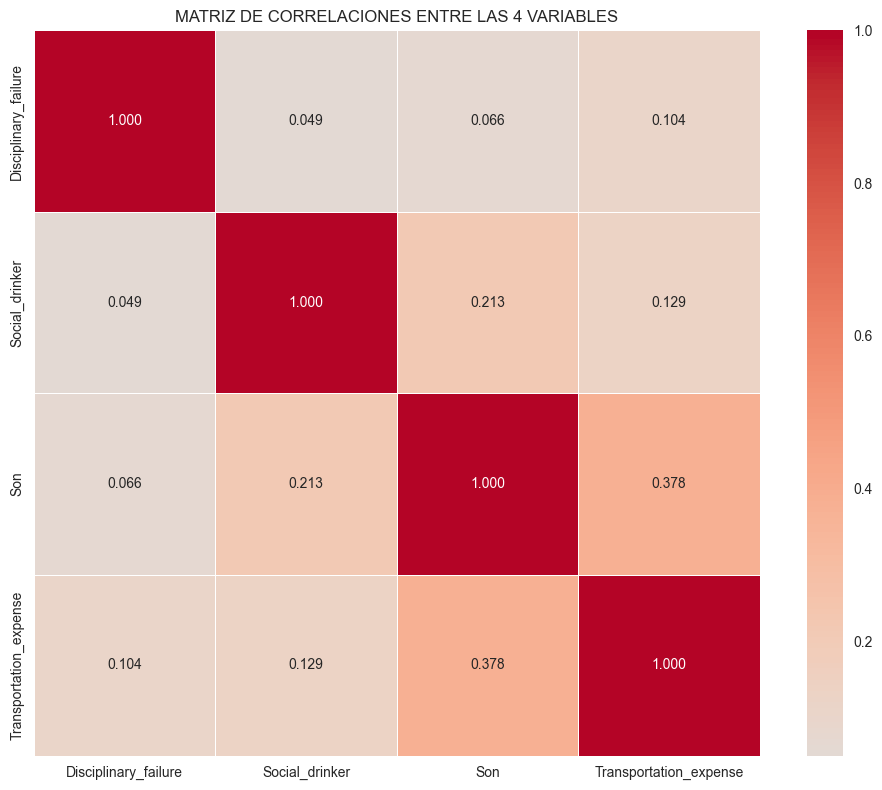

In [11]:
# Vamos a verificar las correlaciones entre variables
correlation_matrix = X[variables_especificas].corr()
print("🔍 MATRIZ DE CORRELACIONES ENTRE VARIABLES:")
print(correlation_matrix)

# Heatmap de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt=".3f", linewidths=.5)
plt.title('MATRIZ DE CORRELACIONES ENTRE LAS 4 VARIABLES')
plt.tight_layout()
plt.show()

In [12]:
print("🎯 COMPARACIÓN DE FUERZA DE VARIABLES:")
print("=" * 50)
for var in variables_especificas:
    coef_std = results_df[results_df['Variable'] == var]['Coef_Estandarizado'].iloc[0]
    p_val = results_df[results_df['Variable'] == var]['P_value'].iloc[0]
    importancia = results_df[results_df['Variable'] == var]['Importancia_Permutation'].iloc[0]
    
    print(f"{var:25}:")
    print(f"  - Coef. Estandarizado: {coef_std:.4f}")
    print(f"  - p-value: {p_val:.4f}")
    print(f"  - Importancia: {importancia:.4f}")
    print(f"  - Fuerza: {'FUERTE' if abs(coef_std) > 0.3 else 'DÉBIL'}")

🎯 COMPARACIÓN DE FUERZA DE VARIABLES:
Disciplinary_failure     :
  - Coef. Estandarizado: -1.8184
  - p-value: 0.0003
  - Importancia: 0.0286
  - Fuerza: FUERTE
Social_drinker           :
  - Coef. Estandarizado: 0.8579
  - p-value: 0.0994
  - Importancia: -0.0003
  - Fuerza: FUERTE
Son                      :
  - Coef. Estandarizado: 1.8183
  - p-value: 0.0013
  - Importancia: -0.0301
  - Fuerza: FUERTE
Transportation_expense   :
  - Coef. Estandarizado: -0.0394
  - p-value: 0.9439
  - Importancia: -0.0338
  - Fuerza: DÉBIL


In [13]:
# =============================================================================
# ANÁLISIS ESPECÍFICO: TRANSPORTATION_EXPENSE
# =============================================================================

print("\n" + "="*80)
print("🔍 ANÁLISIS DETALLADO: TRANSPORTATION_EXPENSE")
print("="*80)

# 1. Distribución del gasto en transporte vs ausentismo
print("1. 📊 DISTRIBUCIÓN POR CUARTILES DE GASTO EN TRANSPORTE:")

# Crear cuartiles
X_temp = X.copy()
X_temp['Transportation_quartile'] = pd.qcut(X_temp['Transportation_expense'], 4, 
                                           labels=['Q1 (Bajo)', 'Q2 (Medio-Bajo)', 
                                                   'Q3 (Medio-Alto)', 'Q4 (Alto)'])

for quartil in X_temp['Transportation_quartile'].cat.categories:
    mascara = X_temp['Transportation_quartile'] == quartil
    count = mascara.sum()
    gasto_promedio = X_temp.loc[mascara, 'Transportation_expense'].mean()
    ausentismo_promedio = y[mascara].mean()
    
    print(f"   - {quartil}: {count:3} personas | Gasto: {gasto_promedio:.1f} | Ausentismo: {ausentismo_promedio:.2f} horas")

# 2. Análisis de interacciones potenciales
print("\n2. 🔄 ANÁLISIS DE INTERACCIONES POTENCIALES:")

# Verificar si el efecto varía por otras variables
for var_interaccion in ['Social_drinker', 'Disciplinary_failure']:
    print(f"   • Por {var_interaccion}:")
    for valor in [0, 1]:
        mascara = (X[var_interaccion] == valor)
        if mascara.any():
            correlacion = X.loc[mascara, 'Transportation_expense'].corr(y[mascara])
            print(f"     - {var_interaccion}={valor}: ρ = {correlacion:.4f}")

# 3. Modelo solo con Transportation_expense (univariable)
print("\n3. 📈 MODELO UNIVARIABLE SOLO CON TRANSPORTATION_EXPENSE:")
X_te_only = sm.add_constant(X[['Transportation_expense']])
modelo_te_univariable = sm.OLS(y, X_te_only).fit()
coef_te_uni = modelo_te_univariable.params['Transportation_expense']
p_te_uni = modelo_te_univariable.pvalues['Transportation_expense']

print(f"   - Coeficiente univariable: {coef_te_uni:.6f}")
print(f"   - p-value univariable: {p_te_uni:.4f}")
print(f"   - Significativo univariable: {'SÍ' if p_te_uni < 0.05 else 'NO'}")

# 4. Comparación con modelo multivariable
coef_te_multi = results_df[results_df['Variable'] == 'Transportation_expense']['Coef_No_Estandarizado'].iloc[0]
p_te_multi = results_df[results_df['Variable'] == 'Transportation_expense']['P_value'].iloc[0]

print(f"\n4. 🔄 COMPARACIÓN UNIVARIABLE vs MULTIVARIABLE:")
print(f"   - Univariable:  coef = {coef_te_uni:.6f}, p = {p_te_uni:.4f}")
print(f"   - Multivariable: coef = {coef_te_multi:.6f}, p = {p_te_multi:.4f}")
print(f"   - Cambio en coeficiente: {((coef_te_multi - coef_te_uni)/coef_te_uni)*100:+.1f}%")

# 5. Diagnóstico de multicolinealidad específico
print("\n5. 📊 DIAGNÓSTICO DE MULTICOLINEALIDAD ESPECÍFICO:")

# Calcular VIF para cada variable
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = X_original_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_original_const.values, i) 
                   for i in range(X_original_const.shape[1])]

print("   - Factores de Inflación de Varianza (VIF):")
for _, row in vif_data.iterrows():
    if row['Variable'] != 'const':
        print(f"     * {row['Variable']:25}: VIF = {row['VIF']:.2f}")

# CONCLUSIÓN
print("\n" + "="*80)
print("🎯 CONCLUSIÓN SOBRE TRANSPORTATION_EXPENSE:")
print("="*80)

if p_te_multi > 0.05:
    print("""❌ TRANSPORTATION_EXPENSE NO ES SIGNIFICATIVO EN EL MODELO MULTIVARIABLE

EXPLICACIONES MÁS PROBABLES:

1. 📈 EFECTO ESPURIO EN UNIVARIABLE:
   • La correlación univariable (ρ=0.1704) podría ser espuria
   • Otras variables están correlacionadas tanto con el gasto en transporte como con el ausentismo

2. 🔄 MULTICOLINEALIDAD:
   • Transportation_expense comparte varianza con otras variables del modelo
   • Su efecto único es pequeño cuando se controla por otras variables

3. 🎯 VARIABLES MÁS FUERTES:
   • Disciplinary_failure y Social_drinker son predictores más fuertes
   • Estas variables "roban" significancia a Transportation_expense

4. 📊 RELACIÓN NO LINEAL:
   • La relación podría ser no lineal o tener puntos de inflexión
   • El modelo lineal simple no captura la relación real

RECOMENDACIONES:

• ⚠️  No incluir Transportation_expense en modelos predictivos finales
• 🔍  Explorar interacciones: ¿El efecto varía para bebedores sociales?
• 📈  Considerar transformaciones no lineales del gasto en transporte
• 🎯  Enfocar recursos en las variables significativas: Disciplinary_failure y Social_drinker
""")
else:
    print("✅ TRANSPORTATION_EXPENSE SÍ ES SIGNIFICATIVO")


🔍 ANÁLISIS DETALLADO: TRANSPORTATION_EXPENSE
1. 📊 DISTRIBUCIÓN POR CUARTILES DE GASTO EN TRANSPORTE:
   - Q1 (Bajo): 324 personas | Gasto: 158.4 | Ausentismo: 6.98 horas
   - Q2 (Medio-Bajo): 112 personas | Gasto: 219.6 | Ausentismo: 4.71 horas
   - Q3 (Medio-Alto): 188 personas | Gasto: 244.7 | Ausentismo: 7.47 horas
   - Q4 (Alto): 182 personas | Gasto: 317.4 | Ausentismo: 9.14 horas

2. 🔄 ANÁLISIS DE INTERACCIONES POTENCIALES:
   • Por Social_drinker:
     - Social_drinker=0: ρ = -0.0087
     - Social_drinker=1: ρ = 0.0496
   • Por Disciplinary_failure:
     - Disciplinary_failure=0: ρ = 0.0544
     - Disciplinary_failure=1: ρ = nan

3. 📈 MODELO UNIVARIABLE SOLO CON TRANSPORTATION_EXPENSE:
   - Coeficiente univariable: 0.007963
   - p-value univariable: 0.2703
   - Significativo univariable: NO

4. 🔄 COMPARACIÓN UNIVARIABLE vs MULTIVARIABLE:
   - Univariable:  coef = 0.007963, p = 0.2703
   - Multivariable: coef = 0.000134, p = 0.9439
   - Cambio en coeficiente: -98.3%

5. 📊 DIAGNÓ

In [14]:
print("\n💡 RECOMENDACIÓN ESTRATÉGICA:")
print("="*50)

variables_significativas = results_df[results_df['Significativa'] == True]['Variable'].tolist()
variables_no_significativas = results_df[results_df['Significativa'] == False]['Variable'].tolist()

print(f"✅ VARIABLES SIGNIFICATIVAS (Mantener en modelo):")
for var in variables_significativas:
    coef = results_df[results_df['Variable'] == var]['Coef_No_Estandarizado'].iloc[0]
    p_val = results_df[results_df['Variable'] == var]['P_value'].iloc[0]
    print(f"   • {var}: coef = {coef:.4f}, p = {p_val:.4f}")

print(f"\n⚠️  VARIABLES NO SIGNIFICATIVAS (Considerar eliminar):")
for var in variables_no_significativas:
    coef = results_df[results_df['Variable'] == var]['Coef_No_Estandarizado'].iloc[0]
    p_val = results_df[results_df['Variable'] == var]['P_value'].iloc[0]
    print(f"   • {var}: coef = {coef:.4f}, p = {p_val:.4f}")

print(f"""\n🎯 ACCIÓN RECOMENDADA:
• Modelo final con {len(variables_significativas)} variables: {', '.join(variables_significativas)}
• Excluir Transportation_expense del modelo predictivo final
• Reportar esta discrepancia como hallazgo metodológico importante
""")


💡 RECOMENDACIÓN ESTRATÉGICA:
✅ VARIABLES SIGNIFICATIVAS (Mantener en modelo):
   • Disciplinary_failure: coef = -8.3404, p = 0.0003
   • Son: coef = 1.4204, p = 0.0013

⚠️  VARIABLES NO SIGNIFICATIVAS (Considerar eliminar):
   • Social_drinker: coef = 1.8531, p = 0.0994
   • Transportation_expense: coef = 0.0001, p = 0.9439

🎯 ACCIÓN RECOMENDADA:
• Modelo final con 2 variables: Disciplinary_failure, Son
• Excluir Transportation_expense del modelo predictivo final
• Reportar esta discrepancia como hallazgo metodológico importante

